# Trinity Football EPA Project - Analysis Script
The purpose of this script is to conduct analysis using the created epa model and its variables. This script will analyze offensive performance

# First Phase
Import the necessary packages and build the dataframe from the exported excel file.

In [1]:
import os
import re
import glob
import pandas as pd
import numpy as np

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# By default this runs on the synthetic sample in data/TU_Games_synthetic so the
# pipeline can be reproduced from a fresh clone. The real Hudl exports are
# private to Trinity Athletics and are not in the repo.
#
# To run on the real data in Colab:
#   from google.colab import drive; drive.mount('/content/drive')
#   os.environ['TUFB_DATA_DIR']       = '/content/drive/MyDrive/TUFB_EPA/TU_Games'
#   os.environ['TUFB_PROCESSED_FILE'] = '/content/drive/MyDrive/TUFB_EPA/TUFB_EPA_Analysis_FULL_DATA.xlsx'
import os
from pathlib import Path

REPO_ROOT      = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR       = Path(os.environ.get('TUFB_DATA_DIR', REPO_ROOT / 'data' / 'TU_Games_synthetic'))
PROCESSED_FILE = Path(os.environ.get('TUFB_PROCESSED_FILE',
                      REPO_ROOT / 'data' / 'processed' / 'TUFB_EPA_Analysis_FULL_DATA.xlsx'))
FIG_DIR        = Path(os.environ.get('TUFB_FIG_DIR', REPO_ROOT / 'figures'))
DOCS_DIR       = Path(os.environ.get('TUFB_DOCS_DIR', REPO_ROOT / 'docs'))
for _d in (PROCESSED_FILE.parent, FIG_DIR, DOCS_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print(f"Game files : {DATA_DIR}")
print(f"Processed  : {PROCESSED_FILE}")

Game files : /mnt/user-data/uploads/TU_Games
Processed  : /root/work/real/TUFB_EPA_Analysis_FULL_DATA.xlsx


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
excel_file = PROCESSED_FILE

df = pd.read_excel(excel_file)
df.head(10)

# Data Reshaping
Reshape necessary columns to be utilized in analysis

In [5]:
# =========================
# RESHAPE NAMING COLUMNS
# =========================

# When odk == "o", team_name = filename_team (first in filename)
# Grab that stable value per game and broadcast it to all rows
game_names = (
    df[df["odk"] == "o"]
    .groupby("game_id")[["team_name", "opp_name"]]
    .first()
    .reset_index()
)

df = df.drop(columns=["team_name", "opp_name"])
df = df.merge(game_names, on="game_id", how="left")

df.head(10)

# Create Trinity Dataframe
Create dataframe focusing on Trinity to use for analysis.

In [6]:
# =========================
# CREATE TU DATAFRAME
# =========================

tu_df = df[df['team_name'] == 'TU'].sort_values(['game_id', 'play']).reset_index(drop=True)
tu_df.head()

Check descriptive stats for tu_df

In [7]:
# tu_df descriptive stats --> compare to model stats

print("\n--- EP by odk ---")
print(tu_df.groupby('odk')['ep'].describe().round(3))

print("\n--- EPA by odk ---")
print(tu_df.groupby('odk')['epa'].describe().round(3))


--- EP by odk ---
      count   mean    std    min    25%    50%    75%    max
odk                                                         
d    4803.0  2.069  1.141 -1.394  1.299  1.836  2.850  5.991
k       0.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN
o    5140.0  2.556  1.332 -1.360  1.555  2.367  3.395  6.790

--- EPA by odk ---
      count   mean    std     min    25%    50%    75%    max
odk                                                          
d    4803.0 -0.173  1.267 -10.409 -0.648 -0.294  0.351  6.771
k     130.0  2.846  2.835  -7.000  3.000  3.000  3.000  7.000
o    5140.0  0.057  1.391 -10.073 -0.557 -0.060  0.653  6.315


# Analysis Visualizations
Analyze offensive trends and performance using visualization.

# Is TU's Offense Generating Positive Value?

EPA by Down Visualization

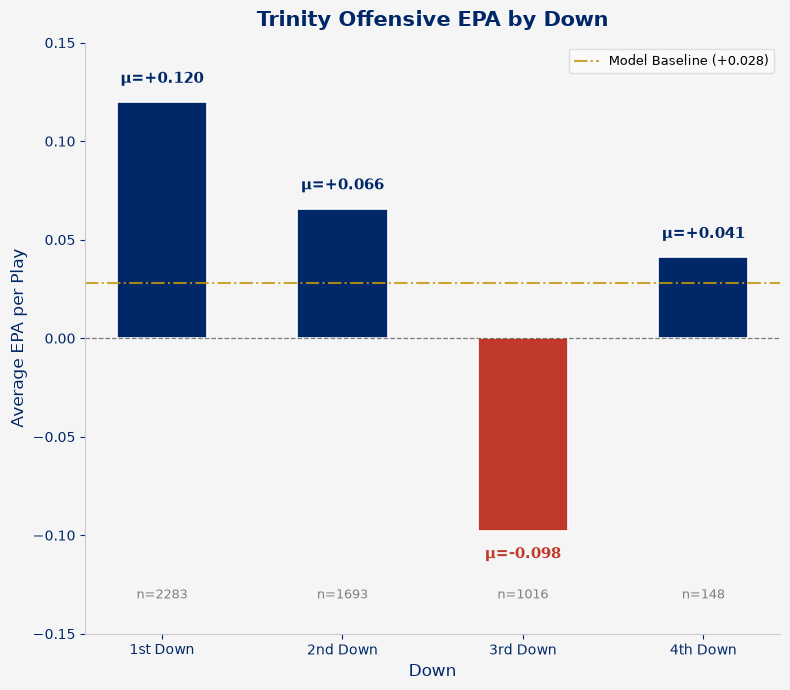

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

# Colors
TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Model average EPA
MODEL_BASELINE = 0.028

# Aggregate by down
down_df = (
    off_df[off_df['dn'].isin([1, 2, 3, 4])]
    .groupby('dn')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)
down_df['dn_label'] = down_df['dn'].map({1: '1st Down', 2: '2nd Down', 3: '3rd Down', 4: '4th Down'})

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(
    down_df['dn_label'],
    down_df['mean'],
    color=[TU_BLUE if v >= 0 else '#C0392B' for v in down_df['mean']],
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, down_df.itertuples()):
    if row.mean >= 0:
        label_y = row.mean + 0.008
        va      = 'bottom'
    else:
        label_y = row.mean - 0.008
        va      = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=11, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.025,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax.set_title('Trinity Offensive EPA by Down', fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Down', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.set_ylim(bottom=-0.15, top=0.15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_by_down.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA vs. Our Opponents

In [9]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
WIN_COLOR  = '#1D9E75'
LOSS_COLOR = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# ── Filter: TU offense, valid EPA ────────────────────────────────────────────
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

# ── One row per game ──────────────────────────────────────────────────────────
game_meta = (
    off_df.groupby('game_id')
    .agg(
        opp_name  = ('opp_name', 'first'),
        game_date = ('game_date', 'first'),
        win       = ('win', 'first'),
        mean_epa  = ('epa', 'mean'),
        sem_epa   = ('epa', 'sem'),
        n_plays   = ('epa', 'count'),
    )
    .reset_index()
)

game_meta['game_date_parsed'] = pd.to_datetime(
    game_meta['game_date'], format='%m/%d/%Y'
)
game_meta['year'] = game_meta['game_date_parsed'].dt.year

def build_label(row):
    result = 'W' if row['win'] == 1 else 'L'
    return f"{row['opp_name']} ({row['year']} {result})"

game_meta['label'] = game_meta.apply(build_label, axis=1)

all_years  = sorted(game_meta['year'].unique())
all_opps   = sorted(game_meta['opp_name'].unique())
overall_mean = off_df['epa'].mean()

# ── Build traces ──────────────────────────────────────────────────────────────
# Scope A: season views — one trace per year + one for all
# Scope B: opponent views — one trace per opponent, chronological

fig = go.Figure()
trace_map = {}   # scope key -> trace index

# Helper: build a bar trace for a given subset and sort order
def make_trace(subset, sort_by, ascending, scope_key, visible):
    subset = subset.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    colors     = [WIN_COLOR if w == 1 else LOSS_COLOR for w in subset['win']]
    hover_text = [
        f"<b>{row['label']}</b><br>"
        f"EPA/play: {row['mean_epa']:+.3f}<br>"
        f"Plays: {int(row['n_plays'])}"
        for _, row in subset.iterrows()
    ]
    idx = len(fig.data)
    fig.add_trace(go.Bar(
        x                = subset['mean_epa'],
        y                = subset['label'],
        orientation      = 'h',
        marker_color      = colors,
        marker_line_color = 'white',
        marker_line_width = 1.2,
        text              = hover_text,
        hovertemplate     = '%{text}<extra></extra>',
        visible           = visible,
        name              = scope_key,
        showlegend        = False,
    ))
    trace_map[scope_key] = idx

# ── Scope A: season traces (sorted by EPA) ────────────────────────────────────
season_scopes = ['All'] + [str(y) for y in all_years]

for scope in season_scopes:
    subset = game_meta if scope == 'All' else game_meta[game_meta['year'] == int(scope)]
    make_trace(subset.copy(), 'mean_epa', True, f'season_{scope}',
               visible=(scope == 'All'))

# ── Scope B: opponent traces (sorted chronologically) ─────────────────────────
for opp in all_opps:
    subset = game_meta[game_meta['opp_name'] == opp].copy()
    make_trace(subset, 'game_date_parsed', True, f'opp_{opp}', visible=False)

total_traces = len(fig.data)

def make_vis(scope_key):
    vis = [False] * total_traces
    vis[trace_map[scope_key]] = True
    return vis

# ── Season buttons ────────────────────────────────────────────────────────────
season_buttons = []
for scope in season_scopes:
    if scope == 'All':
        subset = game_meta.copy()
    else:
        subset = game_meta[game_meta['year'] == int(scope)].copy()
    n_games  = len(subset)
    n_wins   = int(subset['win'].sum())
    n_losses = n_games - n_wins
    avg      = subset['mean_epa'].mean()

    season_buttons.append(dict(
        label  = scope,
        method = 'update',
        args   = [
            {'visible': make_vis(f'season_{scope}')},
            {'title.text': (
                f'<b>TU Offensive EPA per Play by Opponent</b>'
                f'{"  —  " + scope if scope != "All" else "  —  All Seasons"}<br>'
                f'<sup>{n_games} games  ·  {n_wins}W–{n_losses}L  ·  '
                f'Avg EPA/play: {avg:+.3f}  ·  Sorted by EPA</sup>'
            ),
            'yaxis.autorange': True}
        ]
    ))

# ── Opponent dropdown ─────────────────────────────────────────────────────────
opp_buttons = []
for opp in all_opps:
    subset   = game_meta[game_meta['opp_name'] == opp].sort_values('game_date_parsed')
    n_games  = len(subset)
    n_wins   = int(subset['win'].sum())
    n_losses = n_games - n_wins
    avg      = subset['mean_epa'].mean()

    opp_buttons.append(dict(
        label  = opp,
        method = 'update',
        args   = [
            {'visible': make_vis(f'opp_{opp}')},
            {'title.text': (
                f'<b>TU vs. {opp}  —  All Seasons</b><br>'
                f'<sup>{n_games} games  ·  {n_wins}W–{n_losses}L  ·  '
                f'Avg EPA/play: {avg:+.3f}  ·  Sorted chronologically</sup>'
            ),
            'yaxis.autorange': True}
        ]
    ))

# ── Reference lines ───────────────────────────────────────────────────────────
fig.add_vline(
    x=overall_mean, line_dash='dash',
    line_color=TU_BLUE, line_width=1.5, opacity=0.6,
    annotation_text=f'Season avg: {overall_mean:+.3f}',
    annotation_position='top',
    annotation_font=dict(color=TU_BLUE, size=10)
)
fig.add_vline(
    x=0, line_dash='dot',
    line_color='black', line_width=1, opacity=0.35
)

fig.add_vline(
    x=MODEL_BASELINE, line_dash='dashdot',
    line_color=TU_GOLD, line_width=2, opacity=0.8,
    annotation_text='Model Baseline (+0.028)',
    annotation_position='bottom',
    annotation_font=dict(color=TU_GOLD, size=10)
)

# ── Layout ────────────────────────────────────────────────────────────────────
n_games_all  = len(game_meta)
n_wins_all   = int(game_meta['win'].sum())
n_losses_all = n_games_all - n_wins_all
avg_all      = game_meta['mean_epa'].mean()

fig.update_layout(
    title=dict(
        text=(
            f'<b>TU Offensive EPA per Play by Opponent</b>  —  All Seasons<br>'
            f'<sup>{n_games_all} games  ·  {n_wins_all}W–{n_losses_all}L  ·  '
            f'Avg EPA/play: {avg_all:+.3f}  ·  Sorted by EPA</sup>'
        ),
        font=dict(size=16, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title='Average EPA per Play',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False,
    ),
    yaxis=dict(
        tickfont=dict(color=TU_BLUE, size=11),
        gridcolor='#DDDDDD',
        autorange=True,
    ),
    updatemenus=[
        # ── Season buttons (top row) ──────────────────────────────────────
        dict(
            type       = 'buttons',
            direction  = 'right',
            showactive = True,
            x=0.5, xanchor='center',
            y=1.10, yanchor='top',
            buttons    = season_buttons,
            bgcolor    = 'white',
            bordercolor= '#CCCCCC',
            font=dict(color=TU_BLUE, size=11),
        ),
        # ── Opponent dropdown (second row) ────────────────────────────────
        dict(
            type       = 'dropdown',
            direction  = 'down',
            showactive = True,
            x=0.5, xanchor='center',
            y=1.03, yanchor='top',
            buttons    = opp_buttons,
            bgcolor    = 'white',
            bordercolor= '#CCCCCC',
            font=dict(color=TU_BLUE, size=11),
        ),
    ],
    annotations=[
        dict(
            text='Season:', showarrow=False,
            x=0.13, xanchor='right',
            y=1.115, yanchor='top',
            xref='paper', yref='paper',
            font=dict(size=10, color='#888888')
        ),
        dict(
            text='Opponent:', showarrow=False,
            x=0.13, xanchor='right',
            y=1.045, yanchor='top',
            xref='paper', yref='paper',
            font=dict(size=10, color='#888888')
        ),
    ],
    plot_bgcolor  = LIGHT_GRAY,
    paper_bgcolor = LIGHT_GRAY,
    hovermode     = 'closest',
    height        = max(500, n_games_all * 28),
    margin        = dict(t=160, b=60, l=200, r=80),
)

fig.show()
fig.write_html(FIG_DIR / 'tu_epa_by_opponent_interactive.html')

# make vertical

# The 3rd Down Problem
3rd down is where drives die.

EPA on 3rd Down by Distance Visualization

/tmp/ipykernel_977/419059841.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




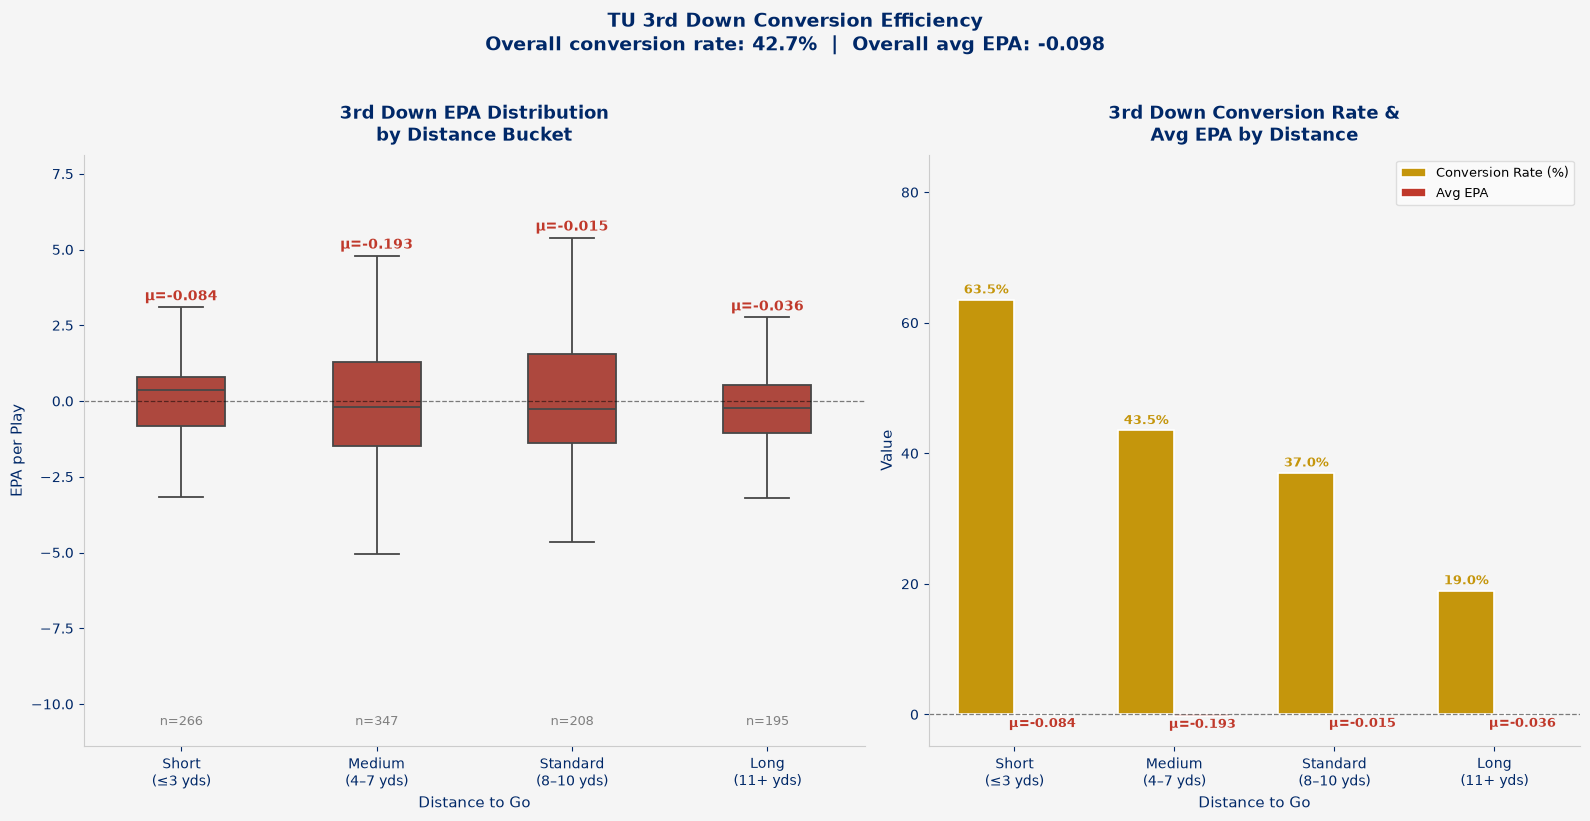

In [10]:
# Filter: TU 3rd down offensive plays with valid EPA
third_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['dist'].notna()) &
    (tu_df['dn'] == 3)
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Bin dist into distance buckets
bins   = [0, 3, 7, 10, float('inf')]
labels = ['Short\n(≤3 yds)', 'Medium\n(4–7 yds)',
          'Standard\n(8–10 yds)', 'Long\n(11+ yds)']

third_df['dist_bucket'] = pd.cut(
    third_df['dist'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Flag conversion
convert_results = ['complete', 'rush', 'scramble', 'complete, td',
                   'rush, td', 'complete, td']
third_df['converted'] = third_df['result'].str.strip().str.lower().isin(
    convert_results
) & (third_df['gn_ls'] >= third_df['dist'])

# Aggregate by distance bucket
bucket_df = (
    third_df.groupby('dist_bucket', observed=True)
    .agg(
        mean_epa    =('epa', 'mean'),
        sem_epa     =('epa', 'sem'),
        count       =('epa', 'count'),
        conv_rate   =('converted', 'mean')
    )
    .reset_index()
)

# Plot: two panels
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={'width_ratios': [1.2, 1]})
fig.patch.set_facecolor(LIGHT_GRAY)

# Left — Box plot of EPA by distance bucket
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

bucket_order  = labels
bucket_colors = {
    b: (TU_BLUE if bucket_df.loc[
        bucket_df['dist_bucket'] == b, 'mean_epa'].values[0] >= 0
        else '#C0392B')
    for b in bucket_order
}

sns.boxplot(
    data=third_df,
    x='dist_bucket', y='epa',
    order=bucket_order,
    palette=bucket_colors,
    width=0.45,
    linewidth=1.3,
    flierprops=dict(marker='o', markersize=3, alpha=0.3,
                    linestyle='none', markeredgewidth=0),
    ax=ax1
)

for i, bucket in enumerate(bucket_order):
    subset      = third_df[third_df['dist_bucket'] == bucket]['epa']
    if len(subset) == 0:
        continue
    mean_val    = subset.mean()
    count       = subset.count()
    Q3          = subset.quantile(0.75)
    IQR         = Q3 - subset.quantile(0.25)
    whisker_top = subset[subset <= Q3 + 1.5 * IQR].max()

    ax1.text(
        i, whisker_top + 0.12,
        f'μ={mean_val:+.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        color=TU_BLUE if mean_val >= 0 else '#C0392B'
    )
    ax1.text(
        i, ax1.get_ylim()[0] + 0.1,
        f'n={count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_title('3rd Down EPA Distribution\nby Distance Bucket',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax1.set_xlabel('Distance to Go', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('EPA per Play', fontsize=11, color=TU_BLUE)
ax1.set_ylim(bottom=ax1.get_ylim()[0] - 0.5,
             top=ax1.get_ylim()[1] + 1.0)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# Right — Conversion rate + avg EPA bar chart
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

x      = range(len(bucket_df))
width  = 0.35
colors = [TU_BLUE if v >= 0 else '#C0392B' for v in bucket_df['mean_epa']]

# Conversion rate bars (left of each pair)
bars1 = ax2.bar(
    [i - width / 2 for i in x],
    bucket_df['conv_rate'] * 100,
    width=width,
    color=TU_GOLD,
    edgecolor='white',
    linewidth=1.2,
    label='Conversion Rate (%)'
)

# Mean EPA bars (right of each pair)
bars2 = ax2.bar(
    [i + width / 2 for i in x],
    bucket_df['mean_epa'],
    width=width,
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    label='Avg EPA'
)

# Annotate conversion rate bars
for bar, row in zip(bars1, bucket_df.itertuples()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row.conv_rate * 100:.1f}%',
        ha='center', va='bottom', fontsize=9,
        fontweight='bold', color=TU_GOLD
    )

# Annotate EPA bars
for bar, row in zip(bars2, bucket_df.itertuples()):
    error_top    = row.mean_epa + row.sem_epa
    error_bottom = row.mean_epa - row.sem_epa
    if row.mean_epa >= 0:
        label_y = error_top + 0.3
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.3
        va      = 'top'
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f'μ={row.mean_epa:+.3f}',
        ha='center', va=va, fontsize=9,
        fontweight='bold',
        color=TU_BLUE if row.mean_epa >= 0 else '#C0392B'
    )

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.set_xticks(list(x))
ax2.set_xticklabels(bucket_df['dist_bucket'], color=TU_BLUE)
ax2.set_title('3rd Down Conversion Rate &\nAvg EPA by Distance',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax2.set_xlabel('Distance to Go', fontsize=11, color=TU_BLUE)
ax2.set_ylabel('Value', fontsize=11, color=TU_BLUE)
ax2.set_ylim(bottom=ax2.get_ylim()[0] - 1.5,
             top=max(bucket_df['conv_rate'] * 100) * 1.35)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')
ax2.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

# Super title
overall_conv  = third_df['converted'].mean() * 100
overall_epa   = third_df['epa'].mean()
fig.suptitle(
    f'TU 3rd Down Conversion Efficiency\n'
    f'Overall conversion rate: {overall_conv:.1f}%  |  '
    f'Overall avg EPA: {overall_epa:+.3f}',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_3rd_down_conversion.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

3rd Down Run vs. Pass EPA by Distance

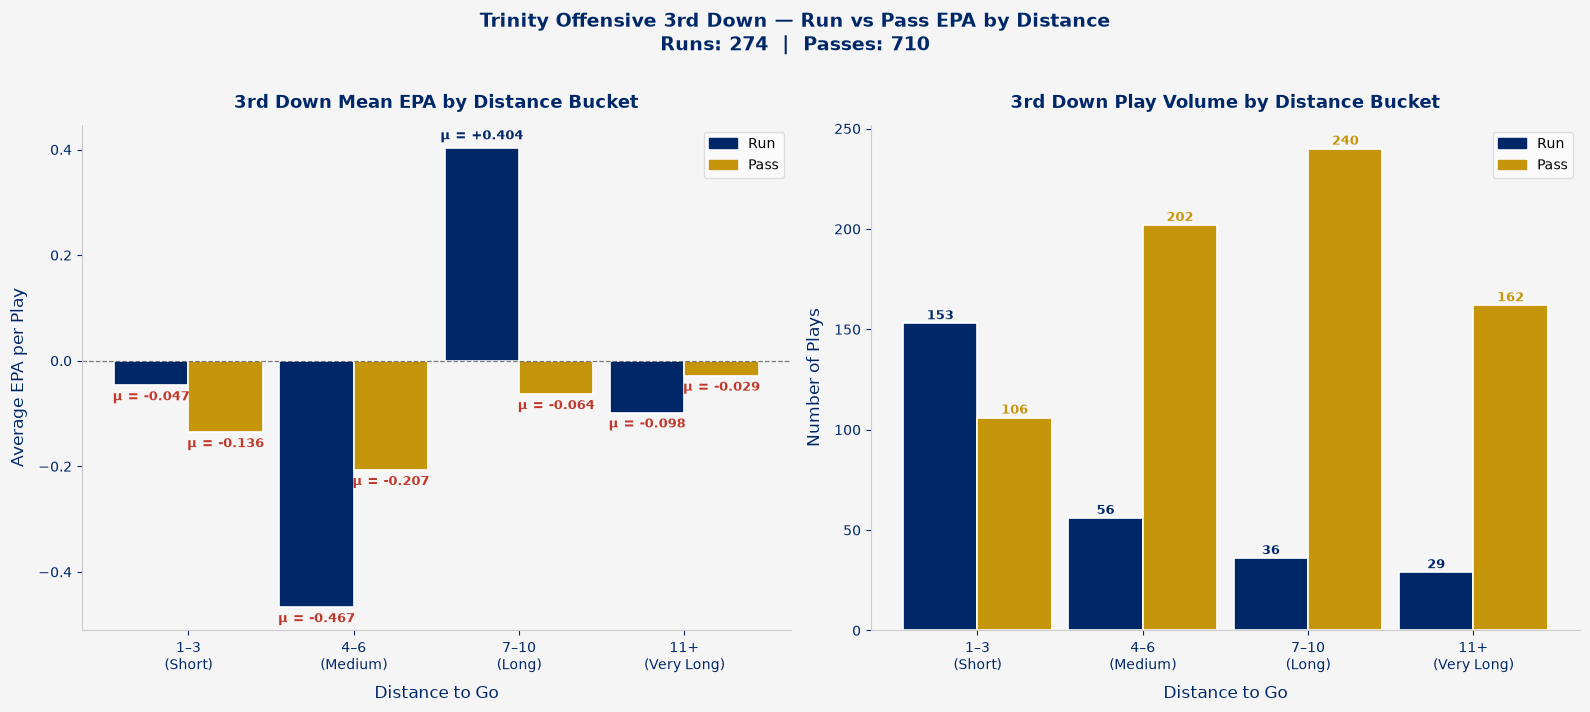

In [11]:
import matplotlib.patches as mpatches

# ── Colors ────────────────────────────────────────────────────────────────────
TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
RED        = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# ── Filter: TU offense, 3rd down, run or pass only ───────────────────────────
third_down = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['dn'] == 3) &
    (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['epa'].notna()) &
    (tu_df['dist'].notna())
].copy()

# ── Distance buckets ──────────────────────────────────────────────────────────
def dist_bucket(d):
    if d <= 3:
        return '1–3\n(Short)'
    elif d <= 6:
        return '4–6\n(Medium)'
    elif d <= 10:
        return '7–10\n(Long)'
    else:
        return '11+\n(Very Long)'

bucket_order = ['1–3\n(Short)', '4–6\n(Medium)', '7–10\n(Long)', '11+\n(Very Long)']

third_down['dist_bucket'] = third_down['dist'].apply(dist_bucket)
third_down['dist_bucket'] = pd.Categorical(third_down['dist_bucket'], categories=bucket_order, ordered=True)

# ── Aggregate ─────────────────────────────────────────────────────────────────
summary = (
    third_down.groupby(['dist_bucket', 'play_type'], observed=True)
    .agg(
        mean_epa=('epa', 'mean'),
        count=('epa', 'count'),
        sem=('epa', lambda x: x.sem())
    )
    .reset_index()
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(LIGHT_GRAY)

bar_width = 0.45
x = np.arange(len(bucket_order))

# run = blue, pass = gold
PLAY_COLOR = {'run': TU_BLUE, 'pass': TU_GOLD}

for ax, metric, ylabel, title_suffix in zip(
    axes,
    ['mean_epa', 'count'],
    ['Average EPA per Play', 'Number of Plays'],
    ['Mean EPA by Distance Bucket', 'Play Volume by Distance Bucket']
):
    ax.set_facecolor(LIGHT_GRAY)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')

    for play_type, offset in [('run', -bar_width / 2), ('pass', bar_width / 2)]:
        base_color = PLAY_COLOR[play_type]
        data = summary[summary['play_type'] == play_type].set_index('dist_bucket').reindex(bucket_order)
        vals = data[metric].values.astype(float)

        if metric == 'mean_epa':
            bars = ax.bar(
                x + offset, vals, bar_width,
                color=[base_color for v in vals],
                edgecolor='white', linewidth=1.2,
                label=play_type.capitalize()
            )

            for bar_obj, val in zip(bars, vals):
                if np.isnan(val):
                    continue
                text_color = RED if val < 0 else base_color
                label_y = val + 0.01 if val >= 0 else val - 0.01
                va = 'bottom' if val >= 0 else 'top'
                ax.text(
                    bar_obj.get_x() + bar_obj.get_width() / 2,
                    label_y, f'μ = {val:+.3f}',
                    ha='center', va=va,
                    fontsize=9, fontweight='bold', color=text_color
                )

        else:
            bars = ax.bar(
                x + offset, vals, bar_width,
                color=base_color,
                edgecolor='white', linewidth=1.2,
                label=play_type.capitalize()
            )

            for bar_obj, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(
                        bar_obj.get_x() + bar_obj.get_width() / 2,
                        bar_obj.get_height() + 0.5,
                        f'{int(val)}',
                        ha='center', va='bottom',
                        fontsize=9, fontweight='bold',
                        color=base_color
                    )

    if metric == 'mean_epa':
        ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(bucket_order, fontsize=10, color=TU_BLUE)
    ax.tick_params(colors=TU_BLUE)
    ax.set_xlabel('Distance to Go', fontsize=12, color=TU_BLUE, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=12, color=TU_BLUE, labelpad=8)
    ax.set_title(f'3rd Down {title_suffix}', fontsize=13, fontweight='bold', color=TU_BLUE, pad=12)

    ax.legend(
        handles=[
            mpatches.Patch(color=TU_BLUE, label='Run'),
            mpatches.Patch(color=TU_GOLD, label='Pass'),
        ],
        fontsize=10, framealpha=0.6, edgecolor='#CCCCCC'
    )

# ── Totals subtitle ───────────────────────────────────────────────────────────
total_runs   = int(summary[summary['play_type'] == 'run']['count'].sum())
total_passes = int(summary[summary['play_type'] == 'pass']['count'].sum())

fig.suptitle(
    f'Trinity Offensive 3rd Down — Run vs Pass EPA by Distance\n'
    f'Runs: {total_runs}  |  Passes: {total_passes}',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.01
)

plt.tight_layout()
plt.savefig(FIG_DIR / '3rd_down_run_pass_epa.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Run vs. Pass EPA by Down

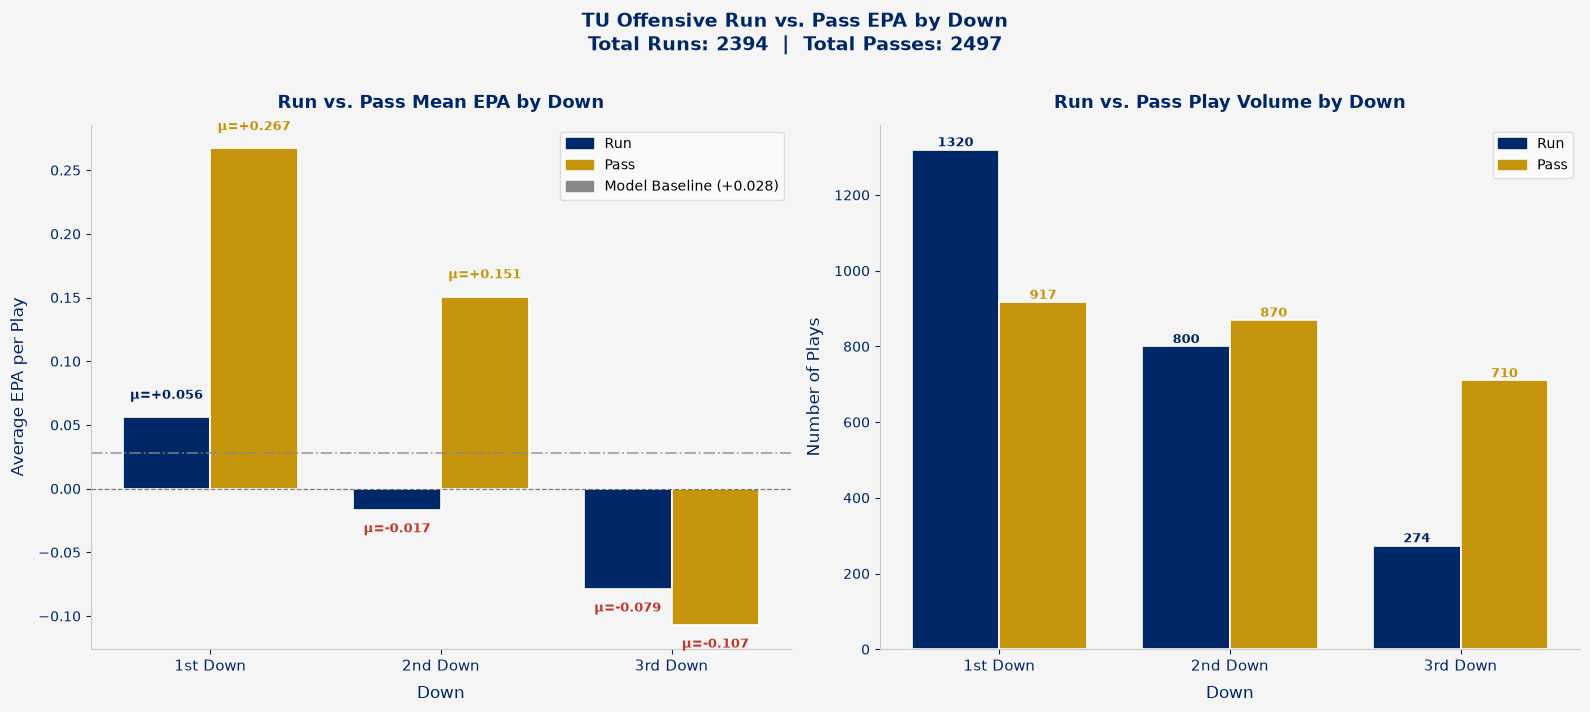

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
RED        = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# Filter: TU offense, runs and passes only, downs 1–3, valid EPA
rp_down = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['dn'].isin([1, 2, 3])) &
    (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['epa'].notna())
].copy()

down_order  = [1, 2, 3]
down_labels = ['1st Down', '2nd Down', '3rd Down']

# Aggregate mean EPA and SEM by down + play_type
summary = (
    rp_down.groupby(['dn', 'play_type'])
    .agg(
        mean_epa = ('epa', 'mean'),
        sem      = ('epa', 'sem'),
        count    = ('epa', 'count')
    )
    .reset_index()
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(LIGHT_GRAY)

bar_width = 0.38
x = np.arange(len(down_order))
PLAY_COLOR = {'run': TU_BLUE, 'pass': TU_GOLD}

# ── Left panel: Mean EPA side-by-side bars ────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

for play_type, offset in [('run', -bar_width / 2), ('pass', bar_width / 2)]:
    data = (
        summary[summary['play_type'] == play_type]
        .set_index('dn')
        .reindex(down_order)
    )
    vals = data['mean_epa'].values.astype(float)
    errs = data['sem'].values.astype(float)
    color = PLAY_COLOR[play_type]

    bars = ax1.bar(
        x + offset, vals, bar_width,
        color=color,
        edgecolor='white', linewidth=1.2,
        label=play_type.capitalize()
    )
    for bar_obj, val in zip(bars, vals):
        if np.isnan(val):
            continue
        text_color = RED if val < 0 else color
        label_y = val + 0.012 if val >= 0 else val - 0.01
        va      = 'bottom' if val >= 0 else 'top'
        ax1.text(
            bar_obj.get_x() + bar_obj.get_width() / 2,
            label_y, f'μ={val:+.3f}',
            ha='center', va=va,
            fontsize=9, fontweight='bold', color=text_color
        )

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.axhline(MODEL_BASELINE, color='#888888', linewidth=1.3, linestyle='-.', alpha=0.75, label='Model Baseline (+0.028)')
ax1.set_xticks(x)
ax1.set_xticklabels(down_labels, fontsize=11, color=TU_BLUE)
ax1.tick_params(colors=TU_BLUE)
ax1.set_xlabel('Down', fontsize=12, color=TU_BLUE, labelpad=8)
ax1.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE, labelpad=8)
ax1.set_title('Run vs. Pass Mean EPA by Down', fontsize=13, fontweight='bold',
              color=TU_BLUE, pad=12)
ax1.legend(
    handles=[
        mpatches.Patch(color=TU_BLUE, label='Run'),
        mpatches.Patch(color=TU_GOLD, label='Pass'),
        mpatches.Patch(color='#888888', label='Model Baseline (+0.028)'),
    ],
    fontsize=10, framealpha=0.6, edgecolor='#CCCCCC'
)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# ── Right panel: Play volume (count) bars ─────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

for play_type, offset in [('run', -bar_width / 2), ('pass', bar_width / 2)]:
    data = (
        summary[summary['play_type'] == play_type]
        .set_index('dn')
        .reindex(down_order)
    )
    vals  = data['count'].values.astype(float)
    color = PLAY_COLOR[play_type]

    bars = ax2.bar(
        x + offset, vals, bar_width,
        color=color,
        edgecolor='white', linewidth=1.2,
        label=play_type.capitalize()
    )

    for bar_obj, val in zip(bars, vals):
        if not np.isnan(val):
            ax2.text(
                bar_obj.get_x() + bar_obj.get_width() / 2,
                bar_obj.get_height() + 0.8,
                f'{int(val)}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=color
            )

ax2.set_xticks(x)
ax2.set_xticklabels(down_labels, fontsize=11, color=TU_BLUE)
ax2.tick_params(colors=TU_BLUE)
ax2.set_xlabel('Down', fontsize=12, color=TU_BLUE, labelpad=8)
ax2.set_ylabel('Number of Plays', fontsize=12, color=TU_BLUE, labelpad=8)
ax2.set_title('Run vs. Pass Play Volume by Down', fontsize=13, fontweight='bold',
              color=TU_BLUE, pad=12)
ax2.legend(
    handles=[
        mpatches.Patch(color=TU_BLUE, label='Run'),
        mpatches.Patch(color=TU_GOLD, label='Pass'),
    ],
    fontsize=10, framealpha=0.6, edgecolor='#CCCCCC'
)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')

# ── Suptitle with totals ──────────────────────────────────────────────────────
total_runs   = int(summary[summary['play_type'] == 'run']['count'].sum())
total_passes = int(summary[summary['play_type'] == 'pass']['count'].sum())

fig.suptitle(
    f'TU Offensive Run vs. Pass EPA by Down\n'
    f'Total Runs: {total_runs}  |  Total Passes: {total_passes}',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.01
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_run_pass_epa_by_down.png', dpi=150, bbox_inches='tight',
            facecolor=LIGHT_GRAY)
plt.show()

# Where on the field do we succeed?

EPA by Field Zone Visualization

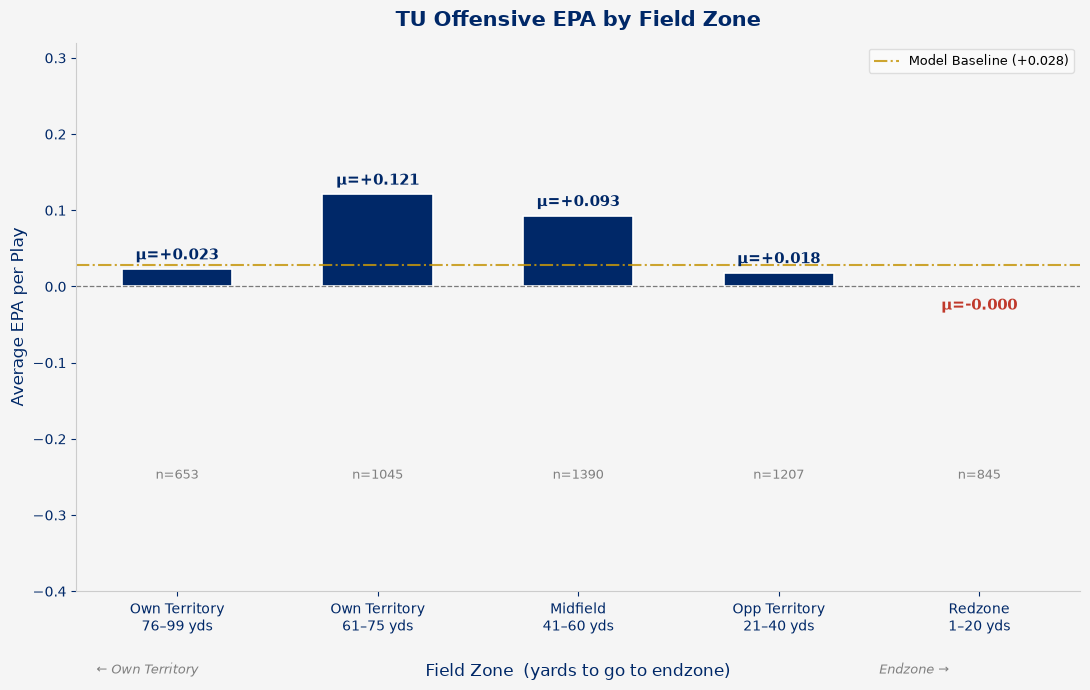

In [13]:
# Filter: TU offensive plays with valid EPA and yards_to_go
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['yards_to_go'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# Bin yards_to_go into field zones
# yards_to_go: 1-99, lower = closer to endzone
# 75-99 = own territory deep, 1-20 = red zone
bins   = [0, 20, 40, 60, 75, 99]
labels = [
    "Redzone\n1–20 yds",
    "Opp Territory\n21–40 yds",
    "Midfield\n41–60 yds",
    "Own Territory\n61–75 yds",
    "Own Territory\n76–99 yds",
]

off_df['field_zone'] = pd.cut(
    off_df['yards_to_go'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Aggregate by field zone
zone_df = (
    off_df.groupby('field_zone', observed=True)['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

# Reverse so x-axis reads left=own territory → right=red zone (toward endzone)
zone_df = zone_df.iloc[::-1].reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in zone_df['mean']]

bars = ax.bar(
    zone_df['field_zone'],
    zone_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

# Annotate bars with mean EPA and play count
for bar, row in zip(bars, zone_df.itertuples()):
    label_y = row.mean + 0.008 if row.mean >= 0 else row.mean - 0.015
    va      = 'bottom' if row.mean >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=11, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.25,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax.set_ylim(bottom=-0.40, top=0.32)

# Direction labels along x-axis
ax.annotate('← Own Territory', xy=(0.02, -0.15), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')
ax.annotate('Endzone →', xy=(0.80, -0.15), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')

ax.set_title('TU Offensive EPA by Field Zone', fontsize=15, fontweight='bold',
             color=TU_BLUE, pad=12)
ax.set_xlabel('Field Zone  (yards to go to endzone)', fontsize=12,
              color=TU_BLUE, labelpad=20)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_by_field_zone_yards_to_go.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Redzone Visualization

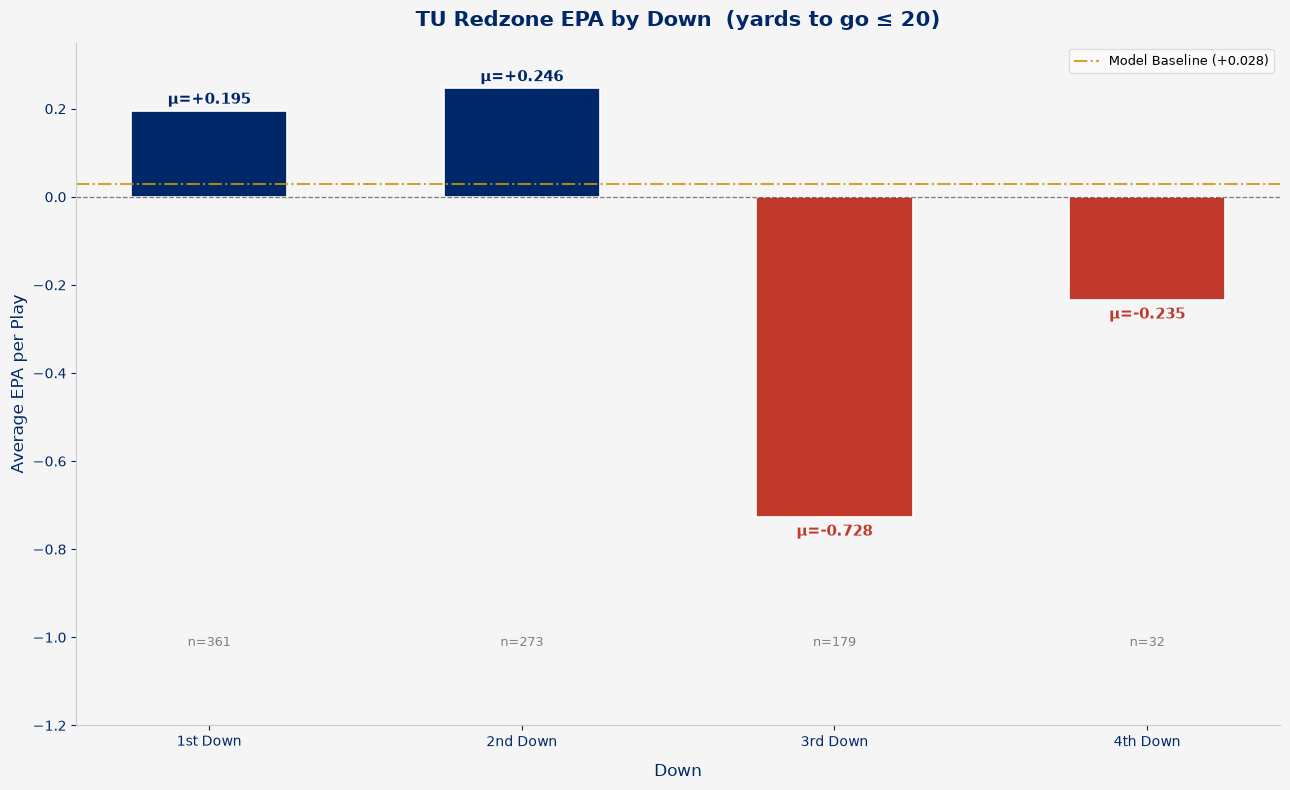

In [14]:
# Filter: TU offensive plays in the red zone with valid EPA and down
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['yards_to_go'].notna()) &
    (tu_df['dn'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'
RED_COLOR  = '#C0392B'

# Model Average EPA
MODEL_BASELINE = 0.028

# Isolate red zone plays (yards_to_go 1–20)
rz_df = off_df[off_df['yards_to_go'] <= 20].copy()

# Down labels
rz_df['down_group'] = rz_df['dn'].map({
    1.0: '1st Down',
    2.0: '2nd Down',
    3.0: '3rd Down',
    4.0: '4th Down',
})
rz_df = rz_df[rz_df['down_group'].notna()]

# Aggregate by down
down_order = ['1st Down', '2nd Down', '3rd Down', '4th Down']
down_agg   = (
    rz_df.groupby('down_group', observed=True)['epa']
    .agg(['mean', 'sem', 'count'])
    .reindex(down_order)
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else RED_COLOR for v in down_agg['mean']]

bars = ax.bar(
    down_agg['down_group'],
    down_agg['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

# Annotate bars
for bar, row in zip(bars, down_agg.itertuples()):
    if pd.isna(row.mean):
        continue
    label_y = row.mean + 0.008 if row.mean >= 0 else row.mean - 0.015
    va      = 'bottom' if row.mean >= 0 else 'top'
    color   = TU_BLUE if row.mean >= 0 else RED_COLOR
    ax.text(bar.get_x() + bar.get_width() / 2, label_y,
            f'μ={row.mean:+.3f}', ha='center', va=va,
            fontsize=11, fontweight='bold', color=color)
    ax.text(bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.25,
            f'n={int(row.count)}', ha='center', va='bottom',
            fontsize=9, color='gray')

ax.set_ylim(bottom=-1.2, top=0.35)
ax.set_title('TU Redzone EPA by Down  (yards to go ≤ 20)',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Down', fontsize=12, color=TU_BLUE, labelpad=10)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_redzone_epa_by_down.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Redzone Run vs. Pass EPA

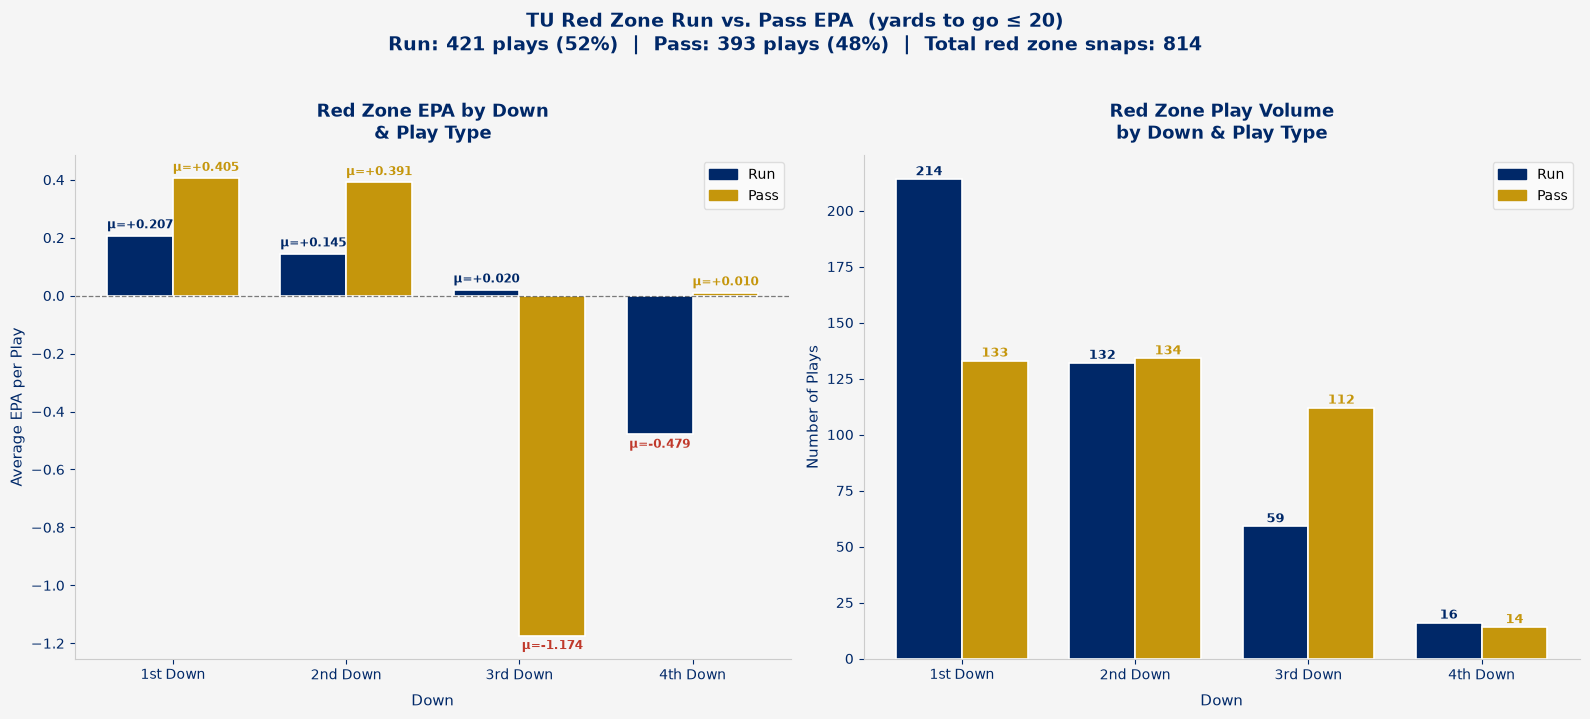

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
RED        = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Filter: TU offense, red zone (yards_to_go ≤ 20), run or pass, valid EPA
rz_rp = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['yards_to_go'].notna()) &
    (tu_df['yards_to_go'] <= 20) &
    (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['epa'].notna()) &
    (tu_df['dn'].isin([1, 2, 3, 4]))
].copy()

down_order  = [1, 2, 3, 4]
down_labels = ['1st Down', '2nd Down', '3rd Down', '4th Down']
PLAY_COLOR  = {'run': TU_BLUE, 'pass': TU_GOLD}

# Aggregate by down + play_type
summary = (
    rz_rp.groupby(['dn', 'play_type'])
    .agg(
        mean_epa = ('epa', 'mean'),
        sem      = ('epa', 'sem'),
        count    = ('epa', 'count')
    )
    .reset_index()
)

# ── Figure: 2 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(LIGHT_GRAY)

bar_width = 0.38
x = np.arange(len(down_order))

# ── Panel 1: Mean EPA by Down + Play Type ─────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

for play_type, offset in [('run', -bar_width / 2), ('pass', bar_width / 2)]:
    data = (
        summary[summary['play_type'] == play_type]
        .set_index('dn')
        .reindex(down_order)
    )
    vals  = data['mean_epa'].values.astype(float)
    errs  = data['sem'].values.astype(float)
    color = PLAY_COLOR[play_type]

    bars = ax1.bar(
        x + offset, vals, bar_width,
        color=color,
        edgecolor='white', linewidth=1.2,
        label=play_type.capitalize()
    )

    for bar_obj, val in zip(bars, vals):
        if np.isnan(val):
            continue
        text_color = RED if val < 0 else color
        label_y = val + 0.015 if val >= 0 else val - 0.015
        va      = 'bottom' if val >= 0 else 'top'
        ax1.text(
            bar_obj.get_x() + bar_obj.get_width() / 2,
            label_y, f'μ={val:+.3f}',
            ha='center', va=va,
            fontsize=8.5, fontweight='bold', color=text_color
        )

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(down_labels, fontsize=10, color=TU_BLUE)
ax1.tick_params(colors=TU_BLUE)
ax1.set_xlabel('Down', fontsize=11, color=TU_BLUE, labelpad=8)
ax1.set_ylabel('Average EPA per Play', fontsize=11, color=TU_BLUE)
ax1.set_title('Red Zone EPA by Down\n& Play Type', fontsize=13,
              fontweight='bold', color=TU_BLUE, pad=12)
ax1.legend(
    handles=[
        mpatches.Patch(color=TU_BLUE, label='Run'),
        mpatches.Patch(color=TU_GOLD, label='Pass'),
    ],
    fontsize=10, framealpha=0.6, edgecolor='#CCCCCC'
)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# ── Panel 2: Play Volume by Down + Play Type ──────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

for play_type, offset in [('run', -bar_width / 2), ('pass', bar_width / 2)]:
    data = (
        summary[summary['play_type'] == play_type]
        .set_index('dn')
        .reindex(down_order)
    )
    vals  = data['count'].values.astype(float)
    color = PLAY_COLOR[play_type]

    bars = ax2.bar(
        x + offset, vals, bar_width,
        color=color,
        edgecolor='white', linewidth=1.2,
        label=play_type.capitalize()
    )

    for bar_obj, val in zip(bars, vals):
        if not np.isnan(val) and val > 0:
            ax2.text(
                bar_obj.get_x() + bar_obj.get_width() / 2,
                bar_obj.get_height() + 0.5,
                f'{int(val)}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=color
            )

ax2.set_xticks(x)
ax2.set_xticklabels(down_labels, fontsize=10, color=TU_BLUE)
ax2.tick_params(colors=TU_BLUE)
ax2.set_xlabel('Down', fontsize=11, color=TU_BLUE, labelpad=8)
ax2.set_ylabel('Number of Plays', fontsize=11, color=TU_BLUE)
ax2.set_title('Red Zone Play Volume\nby Down & Play Type', fontsize=13,
              fontweight='bold', color=TU_BLUE, pad=12)
ax2.legend(
    handles=[
        mpatches.Patch(color=TU_BLUE, label='Run'),
        mpatches.Patch(color=TU_GOLD, label='Pass'),
    ],
    fontsize=10, framealpha=0.6, edgecolor='#CCCCCC'
)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')

# ── Suptitle ──────────────────────────────────────────────────────────────────
run_total  = int(summary[summary['play_type'] == 'run']['count'].sum())
pass_total = int(summary[summary['play_type'] == 'pass']['count'].sum())
total_rz   = run_total + pass_total
run_pct    = run_total  / total_rz * 100 if total_rz else 0
pass_pct   = pass_total / total_rz * 100 if total_rz else 0

fig.suptitle(
    f'TU Red Zone Run vs. Pass EPA  (yards to go ≤ 20)\n'
    f'Run: {run_total} plays ({run_pct:.0f}%)  |  '
    f'Pass: {pass_total} plays ({pass_pct:.0f}%)  |  '
    f'Total red zone snaps: {total_rz}',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_redzone_run_pass_epa.png', dpi=150, bbox_inches='tight',
            facecolor=LIGHT_GRAY)
plt.show()

# How Plays Finished.

EPA by Result Types

/tmp/ipykernel_977/3287559683.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




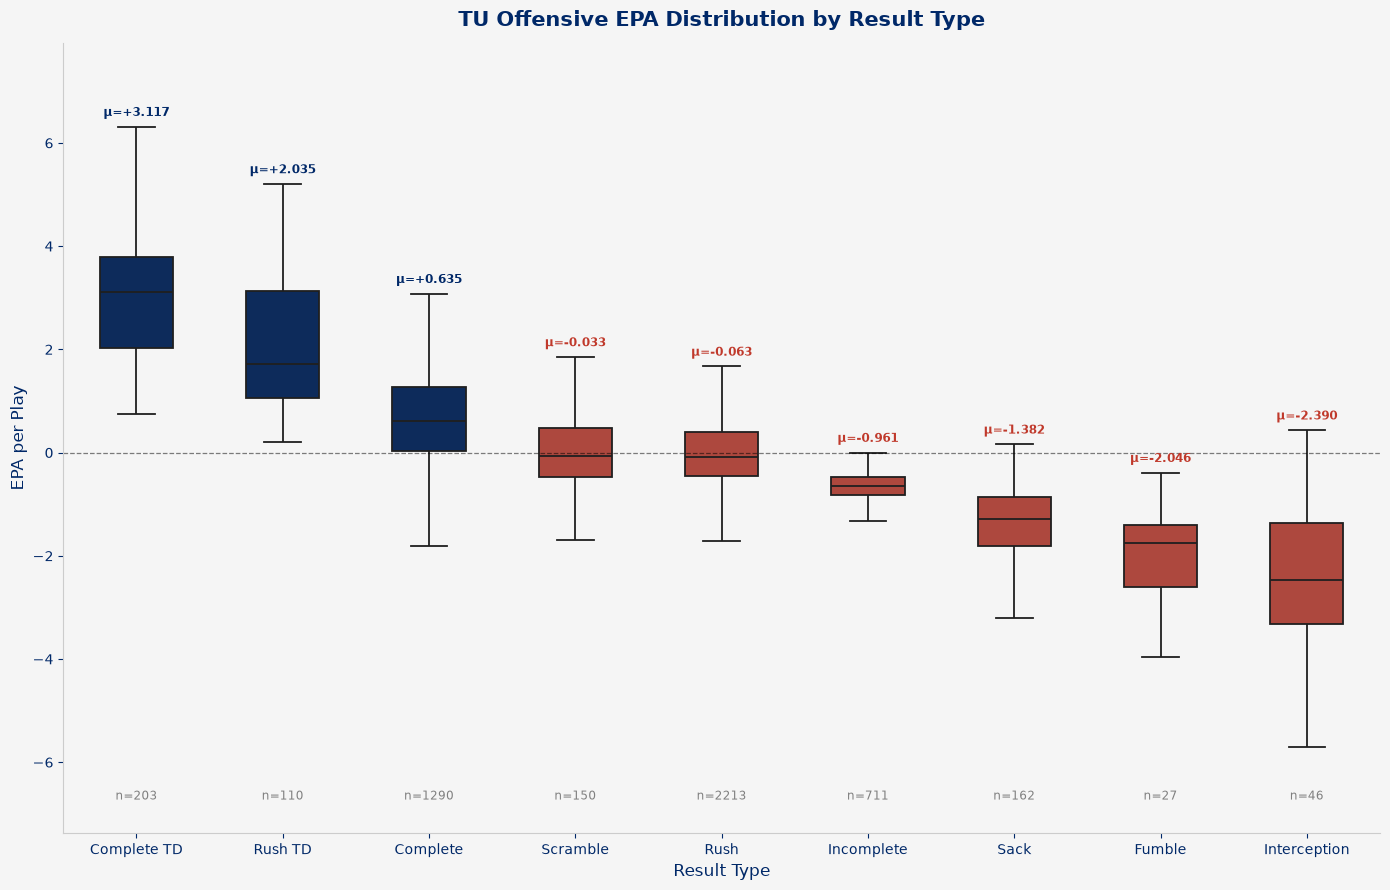

In [16]:
# Filter: TU offensive plays with valid EPA and result
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['result'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Clean and filter result types
off_df['result'] = off_df['result'].str.strip().str.lower()

keep_results = ['rush', 'complete', 'incomplete', 'interception',
                'sack', 'scramble', 'complete, td', 'rush, td', 'fumble']

off_df = off_df[off_df['result'].isin(keep_results)].copy()

label_map = {
    'rush'        : 'Rush',
    'complete'    : 'Complete',
    'incomplete'  : 'Incomplete',
    'interception': 'Interception',
    'sack'        : 'Sack',
    'scramble'    : 'Scramble',
    'complete, td': 'Complete TD',
    'rush, td'    : 'Rush TD',
    'fumble'      : 'Fumble'
}
off_df['result_label'] = off_df['result'].map(label_map)

# Order by median EPA descending
result_order = (
    off_df.groupby('result_label')['epa']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Color — positive median = TU Blue, negative = red
median_vals = off_df.groupby('result_label')['epa'].median()
box_colors  = [
    TU_BLUE if median_vals[r] >= 0 else '#C0392B'
    for r in result_order
]

# Plot
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

sns.boxplot(
    data=off_df,
    x='result_label', y='epa',
    order=result_order,
    palette={r: c for r, c in zip(result_order, box_colors)},
    width=0.5,
    linewidth=1.3,
    flierprops=dict(
        marker='o', markersize=3,
        alpha=0.3, linestyle='none',
        markeredgewidth=0
    ),
    ax=ax
)

# Compute whisker tops and place mean labels above them
for i, result in enumerate(result_order):
    subset   = off_df[off_df['result_label'] == result]['epa']
    mean_val = subset.mean()
    count    = subset.count()
    Q3       = subset.quantile(0.75)
    IQR      = subset.quantile(0.75) - subset.quantile(0.25)
    whisker_top = subset[subset <= Q3 + 1.5 * IQR].max()

    # Mean label just above the top whisker
    ax.text(
        i, whisker_top + 0.15,
        f'μ={mean_val:+.3f}',
        ha='center', va='bottom',
        fontsize=8.5, fontweight='bold',
        color=TU_BLUE if median_vals[result] >= 0 else '#C0392B'
    )

    # n= always at the bottom
    ax.text(
        i, ax.get_ylim()[0] + 0.1, f'n={count}',
        ha='center', va='bottom', fontsize=8.5, color='gray'
    )

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

ax.set_title('TU Offensive EPA Distribution by Result Type',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Result Type', fontsize=12, color=TU_BLUE)
ax.set_ylabel('EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0] - 0.5, top=ax.get_ylim()[1] + 1.0)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_by_result_type.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Run vs. Pass Distribution

/tmp/ipykernel_977/1607555798.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_977/1607555798.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




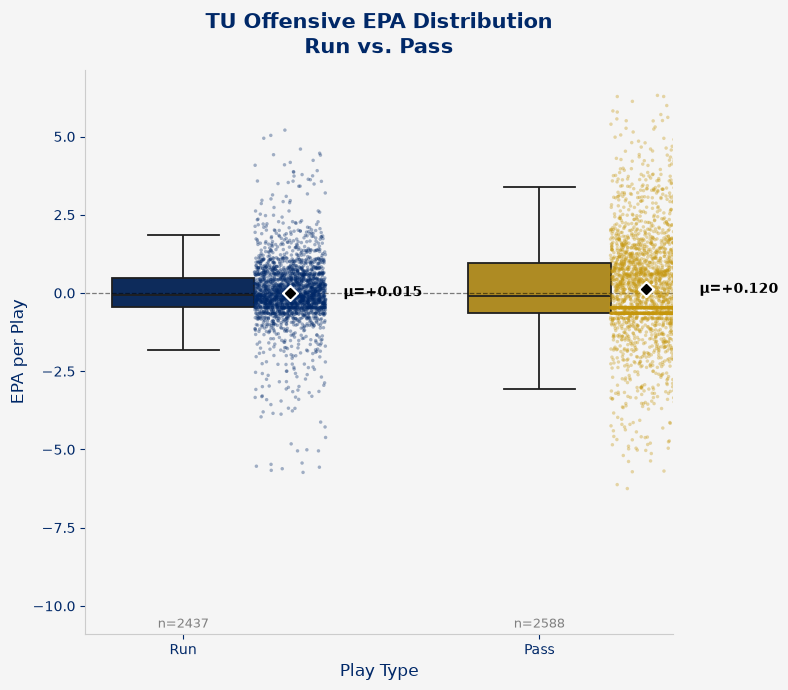

In [17]:
# Filter: run/pass offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

rp_df = off_df[off_df['play_type'].isin(['run', 'pass'])].copy()
rp_df['play_type'] = rp_df['play_type'].str.capitalize()

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

palette = {'Run': TU_BLUE, 'Pass': TU_GOLD}

sns.boxplot(
    data=rp_df,
    x='play_type', y='epa',
    palette=palette,
    order=['Run', 'Pass'],
    width=0.4,
    linewidth=1.3,
    flierprops=dict(marker='', markersize=0),  # hide default fliers since strip covers them
    ax=ax
)

sns.stripplot(
    data=rp_df,
    x='play_type', y='epa',
    palette=palette,
    order=['Run', 'Pass'],
    size=2.5,
    alpha=0.35,
    jitter=True,
    ax=ax
)

# Nudge each strip plot group to the right of its box
OFFSET = 0.3
for i, collection in enumerate(ax.collections):
    offsets = collection.get_offsets()
    offsets[:, 0] += OFFSET
    collection.set_offsets(offsets)

# Mean markers (also nudged to sit alongside the strip)
for i, pt in enumerate(['Run', 'Pass']):
    mean_val = rp_df[rp_df['play_type'] == pt]['epa'].mean()
    count    = rp_df[rp_df['play_type'] == pt].shape[0]
    ax.plot(i + OFFSET, mean_val, marker='D', color='white', markersize=8, zorder=5)
    ax.plot(i + OFFSET, mean_val, marker='D', color='black', markersize=5, zorder=6)
    ax.text(i + OFFSET + 0.15, mean_val, f'μ={mean_val:+.3f}',
            va='center', fontsize=10, fontweight='bold', color='black')
    ax.text(i, ax.get_ylim()[0] + 0.2, f'n={count}',
            ha='center', fontsize=9, color='gray')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

ax.set_title('TU Offensive EPA Distribution\nRun vs. Pass', fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Play Type', fontsize=12, color=TU_BLUE)
ax.set_ylabel('EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Run', 'Pass'])
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_run_vs_pass.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA by Distance to go

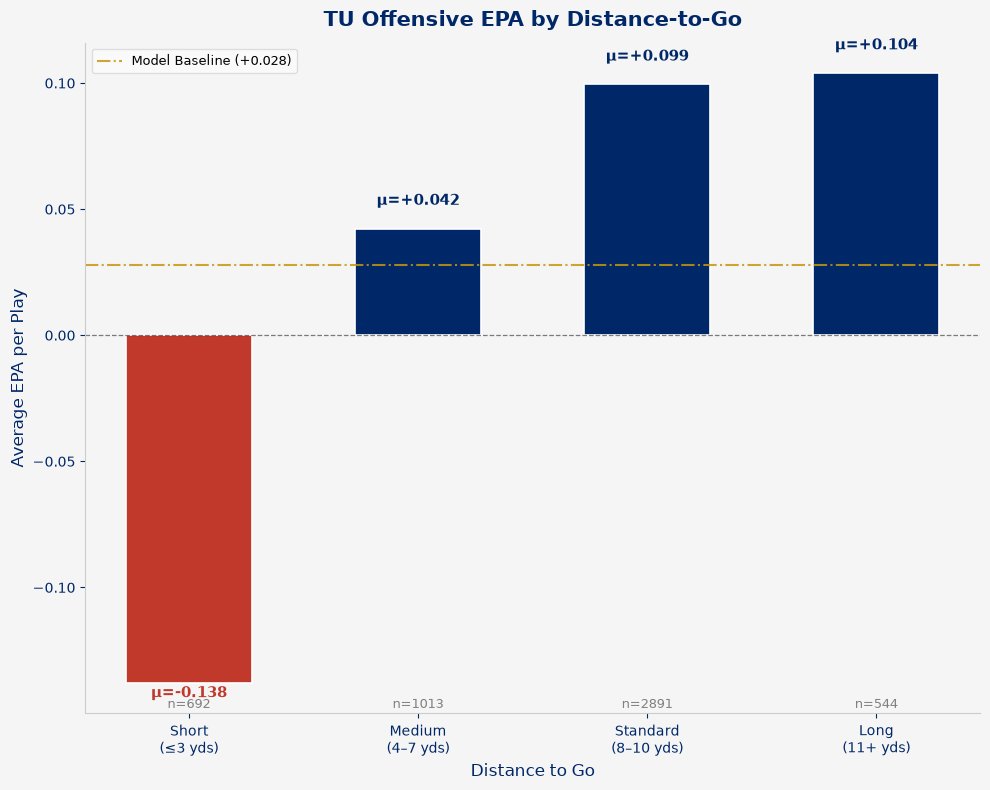

In [18]:
# Filter: TU offensive plays with valid EPA and dist
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['dist'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# Bin dist into distance buckets
bins   = [0, 3, 7, 10, float('inf')]
labels = ['Short\n(≤3 yds)', 'Medium\n(4–7 yds)', 'Standard\n(8–10 yds)', 'Long\n(11+ yds)']

off_df['dist_bucket'] = pd.cut(
    off_df['dist'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Aggregate by distance bucket
dist_df = (
    off_df.groupby('dist_bucket', observed=True)['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in dist_df['mean']]

bars = ax.bar(
    dist_df['dist_bucket'],
    dist_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

# Annotations
for bar, row in zip(bars, dist_df.itertuples()):
    label_y = row.mean + 0.008 if row.mean >= 0 else row.mean - 0.001
    va      = 'bottom' if row.mean >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=11, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] + 0.001,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax.set_title('TU Offensive EPA by Distance-to-Go',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Distance to Go', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_by_distance.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

# Our Scheme - Personnel and Formation

EPA by Personnel Visualization

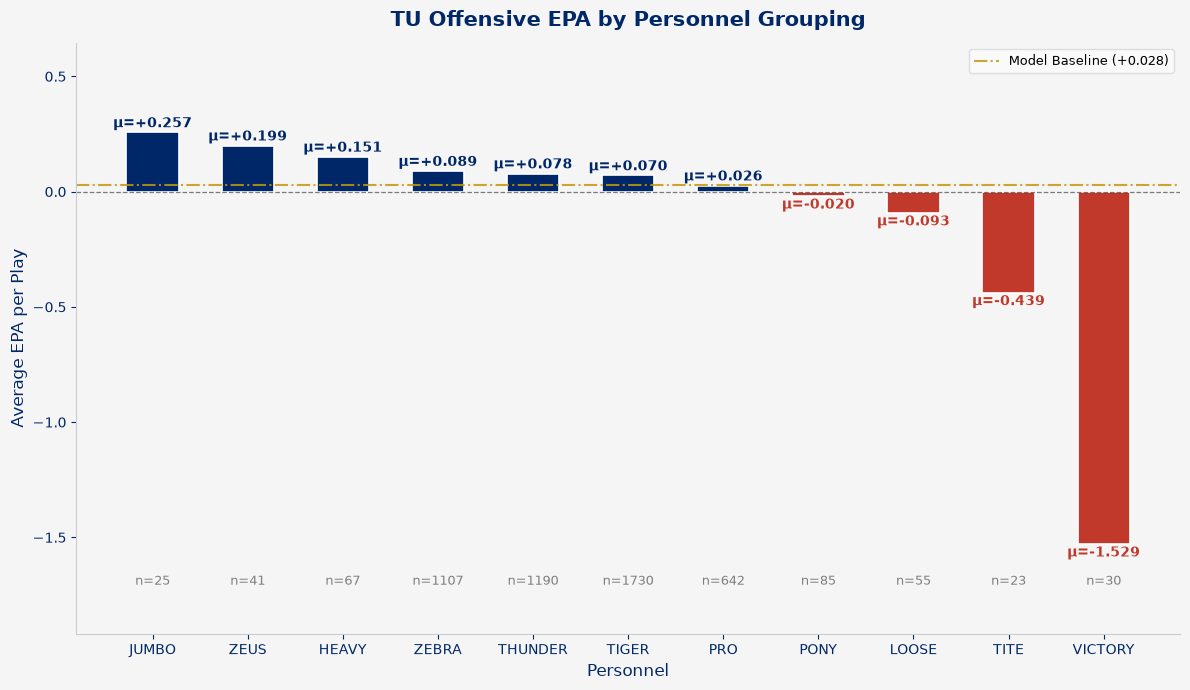

In [19]:
# Filter: TU offensive plays with valid EPA and personnel
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['personnel'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# Aggregate by personnel
pers_df = (
    off_df.groupby('personnel')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

pers_df = pers_df[pers_df['count'] >= 20].sort_values('mean', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in pers_df['mean']]

bars = ax.bar(
    pers_df['personnel'],
    pers_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

# Annotation Loop:
for bar, row in zip(bars, pers_df.itertuples()):
    label_y = row.mean + 0.008 if row.mean >= 0 else row.mean - 0.008
    va      = 'bottom' if row.mean >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=10, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.1,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax.set_title('TU Offensive EPA by Personnel Grouping',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Personnel', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0] - 0.3, top=ax.get_ylim()[1] + 0.3)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_by_personnel.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA by Formation

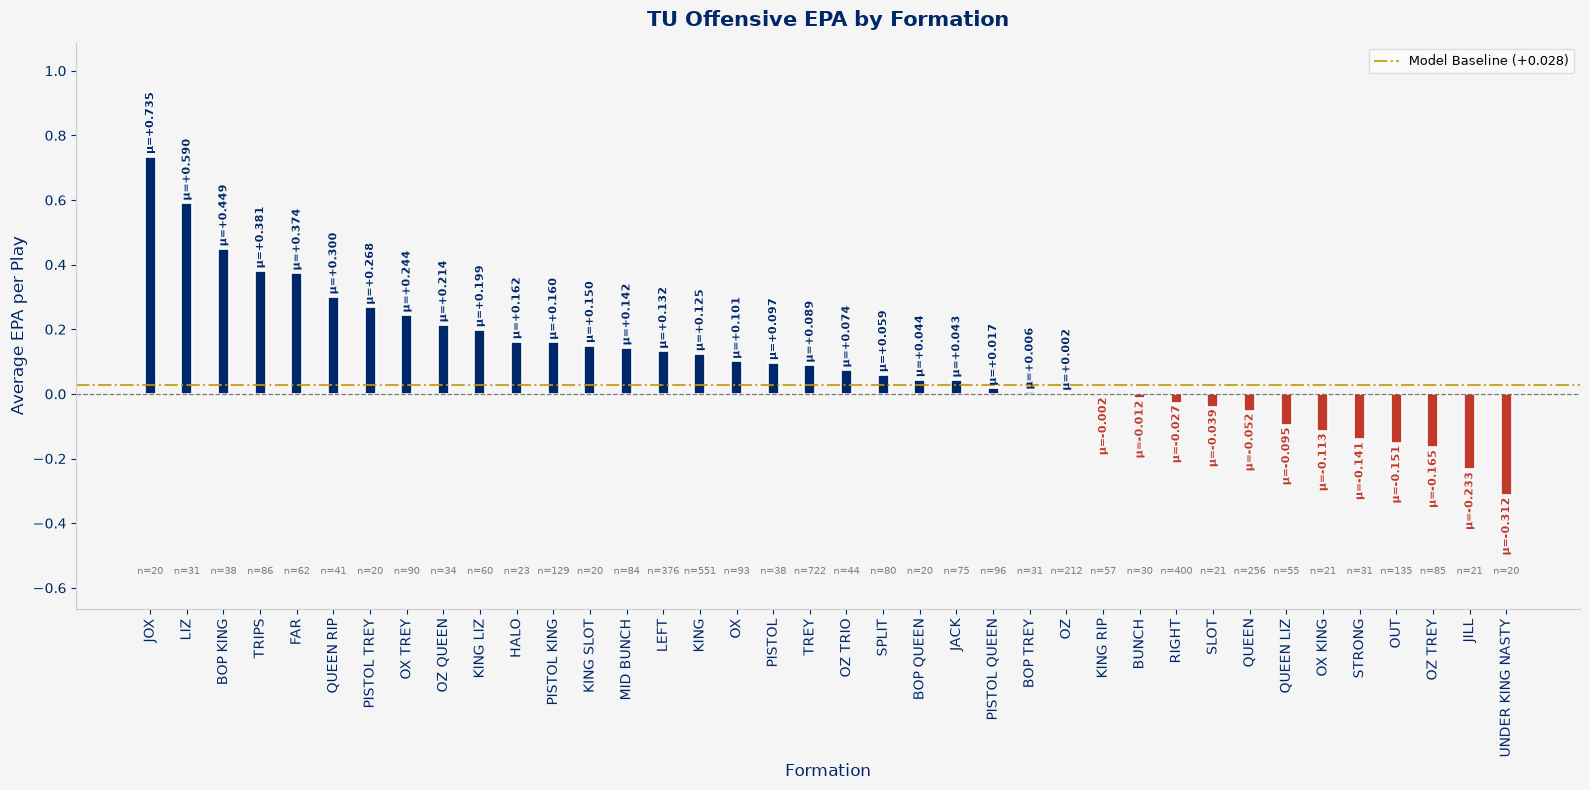

In [20]:
# ── Filter: TU offensive plays with valid EPA and off_form ────────────────────
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['off_form'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# ── Normalize formation — collapse RIGHT/LEFT variants ────────────────────────
def normalize_formation(form):
    form = str(form).strip().upper()
    # If the formation is ONLY the word RIGHT or LEFT, keep it as-is
    if form in ['RIGHT', 'LEFT']:
        return form
    # Otherwise strip trailing or leading RIGHT/LEFT to get the base name
    form = re.sub(r'\bRIGHT\b', '', form)
    form = re.sub(r'\bLEFT\b', '', form)
    form = ' '.join(form.split())   # clean up extra whitespace
    return form if form else 'OTHER'

off_df['form_normalized'] = off_df['off_form'].apply(normalize_formation)

# ── Aggregate by normalized formation ────────────────────────────────────────
form_df = (
    off_df.groupby('form_normalized')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

form_df = form_df[form_df['count'] >= 20].sort_values('mean', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in form_df['mean']]

bars = ax.bar(
    form_df['form_normalized'],
    form_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.3
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, form_df.itertuples()):
    label_y = row.mean + 0.008 if row.mean >= 0 else row.mean - 0.008
    va      = 'bottom' if row.mean >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=8, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B',
        rotation=90
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.2,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=7.5, color='gray'
    )

ax.set_title('TU Offensive EPA by Formation',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Formation', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0] - 0.3, top=ax.get_ylim()[1] + 0.3)
ax.tick_params(axis='x', colors=TU_BLUE, rotation=90)
ax.tick_params(axis='y', colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_by_formation.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA by Personnel and Formation Visualization

In [21]:
# Filter
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['personnel'].notna()) &
    (tu_df['off_form'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# Normalize formation
def normalize_formation(form):
    form = str(form).strip().upper()
    if form in ['RIGHT', 'LEFT']:
        return form
    form = re.sub(r'\bRIGHT\b', '', form)
    form = re.sub(r'\bLEFT\b', '', form)
    form = ' '.join(form.split())
    return form if form else 'OTHER'

off_df['form_normalized'] = off_df['off_form'].apply(normalize_formation)

# Aggregate by personnel + formation combination
combo_df = (
    off_df.groupby(['personnel', 'form_normalized'])['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
    .rename(columns={'form_normalized': 'formation'})
)

combo_df = combo_df[combo_df['count'] >= 10].copy()

# Sort personnel by avg EPA
personnel_list = (
    combo_df.groupby('personnel')['mean']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Color palette for personnel
pers_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]
pers_color_map = {p: pers_colors[i % len(pers_colors)]
                  for i, p in enumerate(personnel_list)}

# Build figure — ONE trace per personnel
# Each trace only contains formations that exist for that personnel
# sorted by mean EPA so best formations appear first on the x axis
fig = go.Figure()

for pers in personnel_list:
    pers_data = (
        combo_df[combo_df['personnel'] == pers]
        .sort_values('mean', ascending=False)
        .reset_index(drop=True)
    )
    color = pers_color_map[pers]

    hover_text = [
        f"<b>{pers} | {row['formation']}</b><br>"
        f"μ EPA: {row['mean']:+.3f}<br>"
        f"n={int(row['count'])}"
        for _, row in pers_data.iterrows()
    ]

    fig.add_trace(go.Bar(
        x=pers_data['formation'],
        y=pers_data['mean'],
        name=pers,
        marker_color=[TU_BLUE if v >= 0 else '#C0392B'
                      for v in pers_data['mean']],
        marker_line_color='white',
        marker_line_width=1.2,
        text=hover_text,
        hovertemplate='%{text}<extra></extra>',
        visible='legendonly',
        legendgroup=pers,
        showlegend=True
    ))

# Zero reference line
fig.add_hline(y=0, line_dash='dash', line_color='black',
              opacity=0.4, line_width=1.5)

n_traces = len(fig.data)

# Layout
fig.update_layout(
    title=dict(
        text='TU Offensive EPA by Personnel & Formation<br>'
             '<sup>Click a personnel group to show its formations — click again to remove</sup>',
        font=dict(size=17, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title='Formation',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        tickangle=45,
        gridcolor='#DDDDDD',
        zeroline=False,
        # Dynamic — only shows formations for visible traces
        autorange=True
    ),
    yaxis=dict(
        title='Average EPA per Play',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False
    ),
    barmode='group',
    legend=dict(
        title=dict(text='Personnel', font=dict(color=TU_BLUE, size=11)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        font=dict(size=10),
        itemclick='toggle',
        itemdoubleclick=False,
    ),
    updatemenus=[
        dict(
            type='buttons',
            showactive=False,
            x=1.0, xanchor='right',
            y=1.08, yanchor='top',
            buttons=[
                dict(
                    label='Show All',
                    method='restyle',
                    args=[{'visible': True}, list(range(n_traces))]
                ),
                dict(
                    label='Hide All',
                    method='restyle',
                    args=[{'visible': 'legendonly'}, list(range(n_traces))]
                )
            ],
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=10)
        )
    ],
    plot_bgcolor=LIGHT_GRAY,
    paper_bgcolor=LIGHT_GRAY,
    hovermode='closest',
    height=650,
    margin=dict(t=120, b=160, l=70, r=20)
)

fig.show()
fig.write_html(FIG_DIR / 'tu_epa_personnel_formation_combo_interactive.html')

Explosive Rate by Personnel

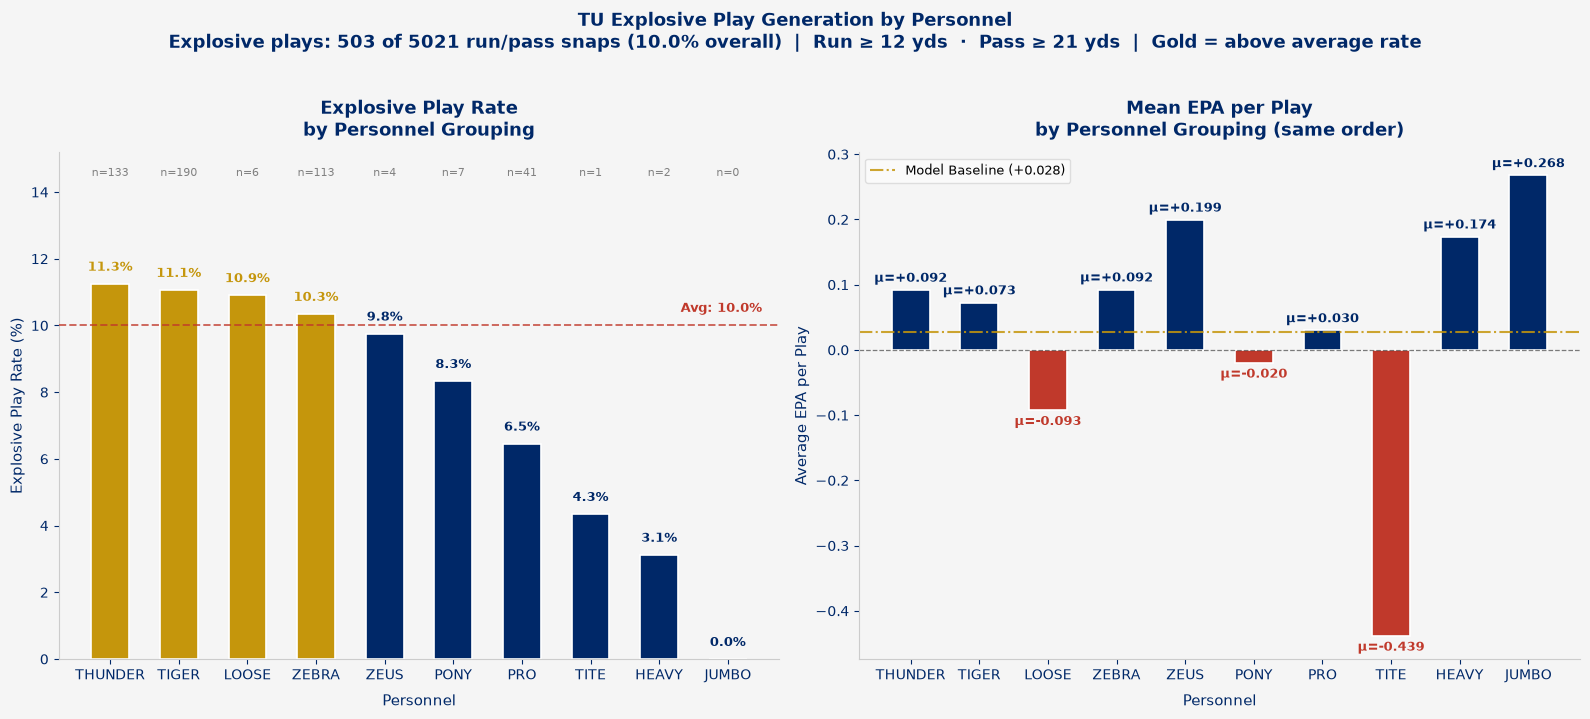

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
RED        = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Model Average EPA
MODEL_BASELINE = 0.028

# Filter: TU offense, run or pass, valid gain and personnel
exp_pers = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['gn_ls'].notna()) &
    (tu_df['personnel'].notna()) &
    (tu_df['epa'].notna())
].copy()

# Flag explosive plays (same definition as existing chart)
exp_pers['explosive'] = (
    ((exp_pers['play_type'] == 'run')  & (exp_pers['gn_ls'] >= 12)) |
    ((exp_pers['play_type'] == 'pass') & (exp_pers['gn_ls'] >= 21))
)

# Aggregate by personnel — min 20 plays to be included
pers_df = (
    exp_pers.groupby('personnel')
    .agg(
        exp_rate  = ('explosive', 'mean'),
        exp_count = ('explosive', 'sum'),
        total     = ('explosive', 'count'),
        mean_epa  = ('epa', 'mean'),
    )
    .reset_index()
)

pers_df = pers_df[pers_df['total'] >= 20].copy()
pers_df['exp_rate_pct'] = pers_df['exp_rate'] * 100

# Sort by explosive rate descending
pers_df = pers_df.sort_values('exp_rate_pct', ascending=False).reset_index(drop=True)

# Overall explosive rate (for reference line)
overall_exp_rate = exp_pers['explosive'].mean() * 100

# ── Plot: two panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(LIGHT_GRAY)

# ── Left panel: Explosive rate % by personnel ─────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_GOLD if v >= overall_exp_rate else TU_BLUE
              for v in pers_df['exp_rate_pct']]

bars = ax1.bar(
    pers_df['personnel'],
    pers_df['exp_rate_pct'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

# Reference line: overall explosive rate
ax1.axhline(overall_exp_rate, color=RED, linewidth=1.4,
            linestyle='--', alpha=0.75, zorder=3)
ax1.text(
    len(pers_df) - 0.5, overall_exp_rate + 0.3,
    f'Avg: {overall_exp_rate:.1f}%',
    ha='right', va='bottom', fontsize=9,
    color=RED, fontweight='bold'
)

ax1.set_ylim(bottom=0, top=pers_df['exp_rate_pct'].max() * 1.35)

for bar, row in zip(bars, pers_df.itertuples()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{row.exp_rate_pct:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
        color=TU_GOLD if row.exp_rate_pct >= overall_exp_rate else TU_BLUE
    )
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        ax1.get_ylim()[1] * 0.97,
        f'n={int(row.exp_count)}',
        ha='center', va='top',
        fontsize=8, color='gray'
    )

ax1.set_title('Explosive Play Rate\nby Personnel Grouping',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=12)
ax1.set_xlabel('Personnel', fontsize=11, color=TU_BLUE, labelpad=8)
ax1.set_ylabel('Explosive Play Rate (%)', fontsize=11, color=TU_BLUE)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# ── Right panel: Mean EPA by personnel (sorted same order) ───────────────────
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

epa_colors = [TU_BLUE if v >= 0 else RED for v in pers_df['mean_epa']]

bars2 = ax2.bar(
    pers_df['personnel'],
    pers_df['mean_epa'],
    color=epa_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.', alpha=0.85, label='Model Baseline (+0.028)')
ax2.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars2, pers_df.itertuples()):
    label_y = row.mean_epa + 0.008 if row.mean_epa >= 0 else row.mean_epa - 0.008
    va      = 'bottom' if row.mean_epa >= 0 else 'top'
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f'μ={row.mean_epa:+.3f}',
        ha='center', va=va,
        fontsize=9, fontweight='bold',
        color=TU_BLUE if row.mean_epa >= 0 else RED
    )

ax2.set_title('Mean EPA per Play\nby Personnel Grouping (same order)',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=12)
ax2.set_xlabel('Personnel', fontsize=11, color=TU_BLUE, labelpad=8)
ax2.set_ylabel('Average EPA per Play', fontsize=11, color=TU_BLUE)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')

# ── Suptitle ──────────────────────────────────────────────────────────────────
total_exp   = int(exp_pers['explosive'].sum())
total_plays = len(exp_pers)

fig.suptitle(
    f'TU Explosive Play Generation by Personnel\n'
    f'Explosive plays: {total_exp} of {total_plays} run/pass snaps '
    f'({overall_exp_rate:.1f}% overall)  |  '
    f'Run ≥ 12 yds  ·  Pass ≥ 21 yds  |  Gold = above average rate',
    fontsize=13, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_explosive_rate_by_personnel.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

# Explosives

Explosive Play EPA vs. Non-explosive Visualization

/tmp/ipykernel_977/757085887.py:47: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




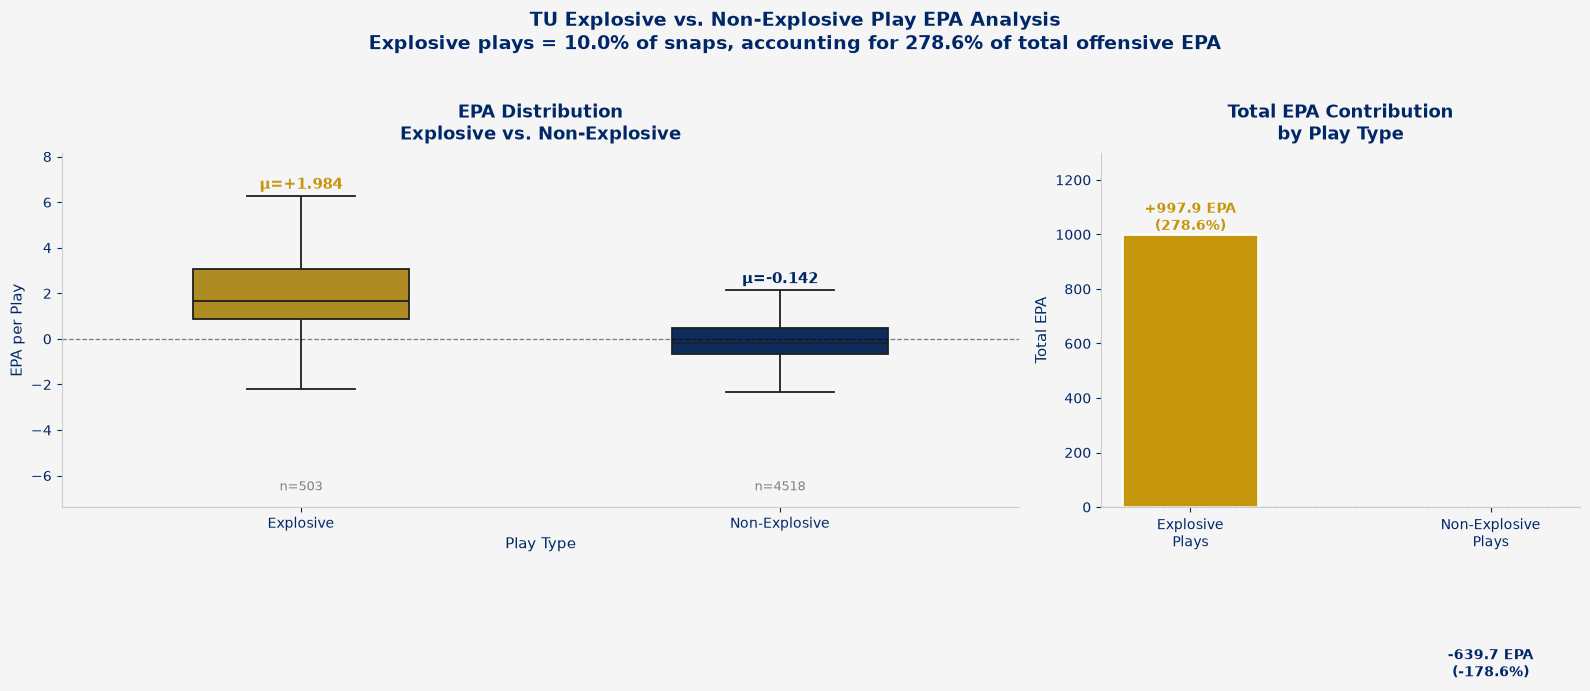

In [23]:
# Filter: TU offensive plays with valid EPA and gn_ls
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['gn_ls'].notna()) &
    (tu_df['play_type'].isin(['run', 'pass']))
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Flag explosive plays
# Run ≥ 12 yards or Pass ≥ 21 yards
off_df['explosive'] = (
    ((off_df['play_type'] == 'run')  & (off_df['gn_ls'] >= 12)) |
    ((off_df['play_type'] == 'pass') & (off_df['gn_ls'] >= 21))
)
off_df['explosive_label'] = off_df['explosive'].map(
    {True: 'Explosive', False: 'Non-Explosive'}
)

# Summary stats
summary = (
    off_df.groupby('explosive_label')['epa']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)

total_epa        = off_df['epa'].sum()
explosive_epa    = off_df[off_df['explosive']]['epa'].sum()
explosive_pct    = (explosive_epa / total_epa * 100) if total_epa != 0 else 0
explosive_play_pct = (off_df['explosive'].sum() / len(off_df) * 100)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor(LIGHT_GRAY)

order   = ['Explosive', 'Non-Explosive']
palette = {'Explosive': TU_GOLD, 'Non-Explosive': TU_BLUE}

# Left — Box plot
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

sns.boxplot(
    data=off_df,
    x='explosive_label', y='epa',
    order=order,
    palette=palette,
    width=0.45,
    linewidth=1.3,
    flierprops=dict(marker='o', markersize=3, alpha=0.3,
                    linestyle='none', markeredgewidth=0),
    ax=ax1
)

# Mean labels above top whisker
for i, label in enumerate(order):
    subset      = off_df[off_df['explosive_label'] == label]['epa']
    mean_val    = subset.mean()
    count       = subset.count()
    Q3          = subset.quantile(0.75)
    IQR         = Q3 - subset.quantile(0.25)
    whisker_top = subset[subset <= Q3 + 1.5 * IQR].max()

    ax1.text(
        i, whisker_top + 0.15,
        f'μ={mean_val:+.3f}',
        ha='center', va='bottom', fontsize=11,
        fontweight='bold',
        color=TU_GOLD if label == 'Explosive' else TU_BLUE
    )
    ax1.text(
        i, ax1.get_ylim()[0] + 0.1,
        f'n={count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_title('EPA Distribution\nExplosive vs. Non-Explosive',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax1.set_xlabel('Play Type', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('EPA per Play', fontsize=11, color=TU_BLUE)
ax1.set_ylim(bottom=ax1.get_ylim()[0] - 0.5, top=ax1.get_ylim()[1] + 1.2)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# Right — EPA contribution bar chart
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

contrib_labels = ['Explosive\nPlays', 'Non-Explosive\nPlays']
contrib_values = [explosive_epa, total_epa - explosive_epa]
contrib_colors = [TU_GOLD, TU_BLUE]

bars = ax2.bar(
    contrib_labels,
    contrib_values,
    color=contrib_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.45
)

for bar, val in zip(bars, contrib_values):
    pct = val / total_epa * 100
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val:+.1f} EPA\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10,
        fontweight='bold',
        color=TU_GOLD if val == explosive_epa else TU_BLUE
    )

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.set_title('Total EPA Contribution\nby Play Type',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax2.set_ylabel('Total EPA', fontsize=11, color=TU_BLUE)
ax2.set_ylim(bottom=0, top=max(contrib_values) * 1.3)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')

# Super title with key context stats
fig.suptitle(
    f'TU Explosive vs. Non-Explosive Play EPA Analysis\n'
    f'Explosive plays = {explosive_play_pct:.1f}% of snaps, '
    f'accounting for {explosive_pct:.1f}% of total offensive EPA',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_epa_explosive_vs_nonexplosive.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Explosives by Field Position

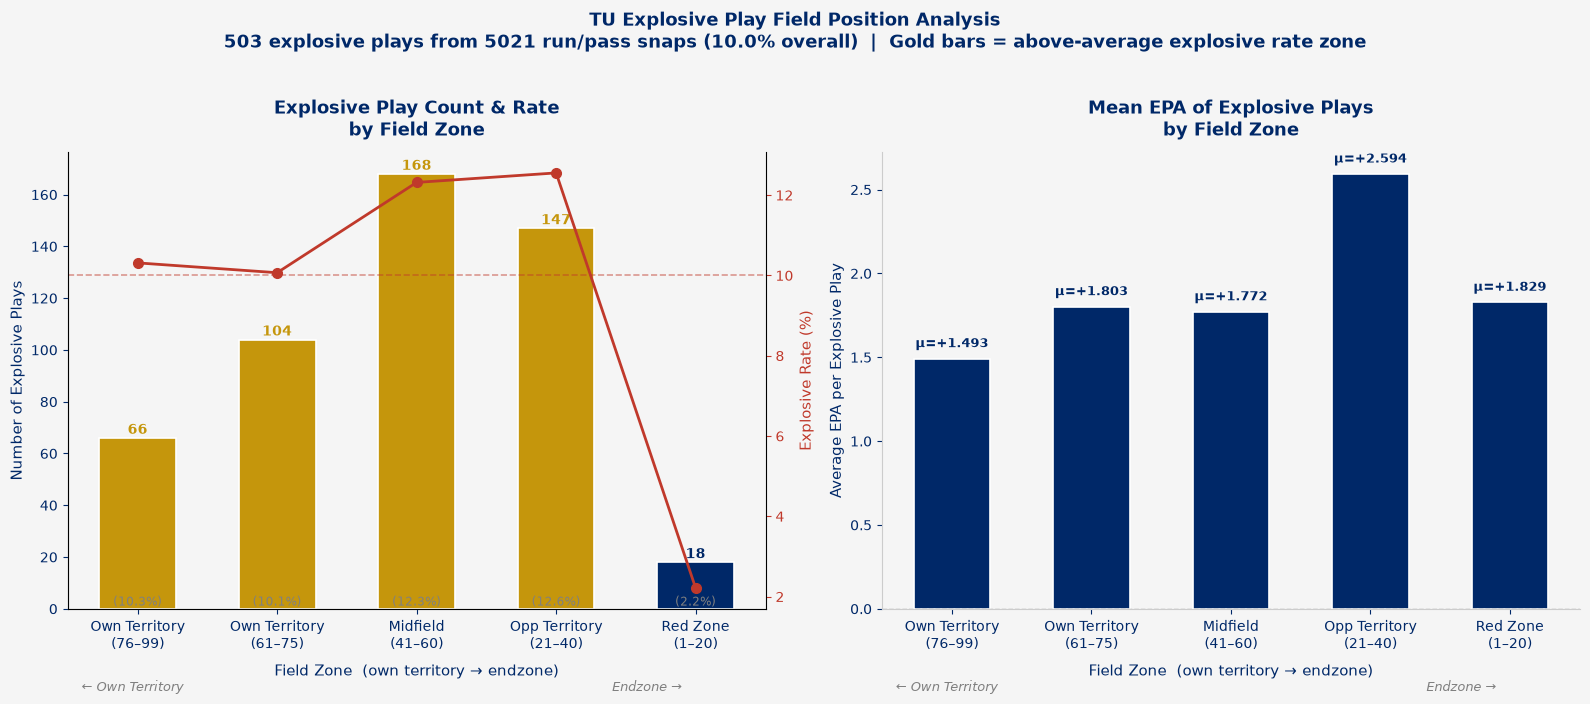

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
RED        = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Filter: TU offense, run or pass, valid yard position and gain
exp_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['gn_ls'].notna()) &
    (tu_df['yards_to_go'].notna()) &
    (tu_df['epa'].notna())
].copy()

# Flag explosive plays
exp_df['explosive'] = (
    ((exp_df['play_type'] == 'run')  & (exp_df['gn_ls'] >= 12)) |
    ((exp_df['play_type'] == 'pass') & (exp_df['gn_ls'] >= 21))
)

# Field zones — same bins as existing field zone chart
# yards_to_go: 1 = goal line, 99 = own end zone
bins   = [0, 20, 40, 60, 75, 99]
labels = [
    'Red Zone\n(1–20)',
    'Opp Territory\n(21–40)',
    'Midfield\n(41–60)',
    'Own Territory\n(61–75)',
    'Own Territory\n(76–99)',
]

exp_df['field_zone'] = pd.cut(
    exp_df['yards_to_go'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Aggregate by field zone
zone_agg = (
    exp_df.groupby('field_zone', observed=True)
    .agg(
        total_plays   = ('explosive', 'count'),
        exp_count     = ('explosive', 'sum'),
        exp_rate      = ('explosive', 'mean'),
        exp_epa_mean  = ('epa', lambda x: x[exp_df.loc[x.index, 'explosive']].mean()),
        exp_epa_sem   = ('epa', lambda x: x[exp_df.loc[x.index, 'explosive']].sem()),
    )
    .reset_index()
)

# Reverse so left = own territory, right = red zone
zone_agg = zone_agg.iloc[::-1].reset_index(drop=True)
zone_agg['exp_rate_pct'] = zone_agg['exp_rate'] * 100

overall_exp_rate = exp_df['explosive'].mean() * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(LIGHT_GRAY)

# ── Left panel: Explosive count (bars) + rate % (line overlay) ───────────────
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_GOLD if r >= overall_exp_rate else TU_BLUE
              for r in zone_agg['exp_rate_pct']]

bars = ax1.bar(
    zone_agg['field_zone'],
    zone_agg['exp_count'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55,
    zorder=2
)

# Count labels on bars
for bar, row in zip(bars, zone_agg.itertuples()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{int(row.exp_count)}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color=TU_GOLD if row.exp_rate_pct >= overall_exp_rate else TU_BLUE
    )
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        0.15,
        f'({row.exp_rate_pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=8.5, color='gray'
    )

# Rate line on twin axis
ax1_twin.plot(
    zone_agg['field_zone'],
    zone_agg['exp_rate_pct'],
    color=RED, linewidth=2, marker='o',
    markersize=7, zorder=3, label='Explosive Rate %'
)
ax1_twin.axhline(overall_exp_rate, color=RED, linewidth=1.2,
                 linestyle='--', alpha=0.5)
ax1_twin.set_ylabel('Explosive Rate (%)', fontsize=11, color=RED)
ax1_twin.tick_params(axis='y', colors=RED)
ax1_twin.spines[['top']].set_visible(False)

ax1.set_title('Explosive Play Count & Rate\nby Field Zone',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=12)
ax1.set_xlabel('Field Zone  (own territory → endzone)', fontsize=11,
               color=TU_BLUE, labelpad=8)
ax1.set_ylabel('Number of Explosive Plays', fontsize=11, color=TU_BLUE)
ax1.tick_params(axis='x', colors=TU_BLUE, rotation=0)
ax1.tick_params(axis='y', colors=TU_BLUE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

ax1.annotate('← Own Territory', xy=(0.02, -0.18), xycoords='axes fraction',
             fontsize=9, color='gray', style='italic')
ax1.annotate('Endzone →', xy=(0.78, -0.18), xycoords='axes fraction',
             fontsize=9, color='gray', style='italic')

# ── Right panel: Mean EPA of explosive plays by zone ─────────────────────────
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

epa_colors = [TU_BLUE if v >= 0 else RED
              for v in zone_agg['exp_epa_mean']]

bars2 = ax2.bar(
    zone_agg['field_zone'],
    zone_agg['exp_epa_mean'],
    color=epa_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

for bar, row in zip(bars2, zone_agg.itertuples()):
    if np.isnan(row.exp_epa_mean):
        continue
    label_y = row.exp_epa_mean + 0.05 if row.exp_epa_mean >= 0 else row.exp_epa_mean - 0.05
    va = 'bottom' if row.exp_epa_mean >= 0 else 'top'
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f'μ={row.exp_epa_mean:+.3f}',
        ha='center', va=va,
        fontsize=9, fontweight='bold',
        color=TU_BLUE if row.exp_epa_mean >= 0 else RED
    )

ax2.set_title('Mean EPA of Explosive Plays\nby Field Zone',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=12)
ax2.set_xlabel('Field Zone  (own territory → endzone)', fontsize=11,
               color=TU_BLUE, labelpad=8)
ax2.set_ylabel('Average EPA per Explosive Play', fontsize=11, color=TU_BLUE)
ax2.tick_params(axis='x', colors=TU_BLUE, rotation=0)
ax2.tick_params(axis='y', colors=TU_BLUE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')

ax2.annotate('← Own Territory', xy=(0.02, -0.18), xycoords='axes fraction',
             fontsize=9, color='gray', style='italic')
ax2.annotate('Endzone →', xy=(0.78, -0.18), xycoords='axes fraction',
             fontsize=9, color='gray', style='italic')

# ── Suptitle ──────────────────────────────────────────────────────────────────
total_exp   = int(exp_df['explosive'].sum())
total_plays = len(exp_df)

fig.suptitle(
    f'TU Explosive Play Field Position Analysis\n'
    f'{total_exp} explosive plays from {total_plays} run/pass snaps '
    f'({overall_exp_rate:.1f}% overall)  |  '
    f'Gold bars = above-average explosive rate zone',
    fontsize=13, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_explosive_field_position.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

# Drive Narrative

Drive-level Cumulative EPA Visualization

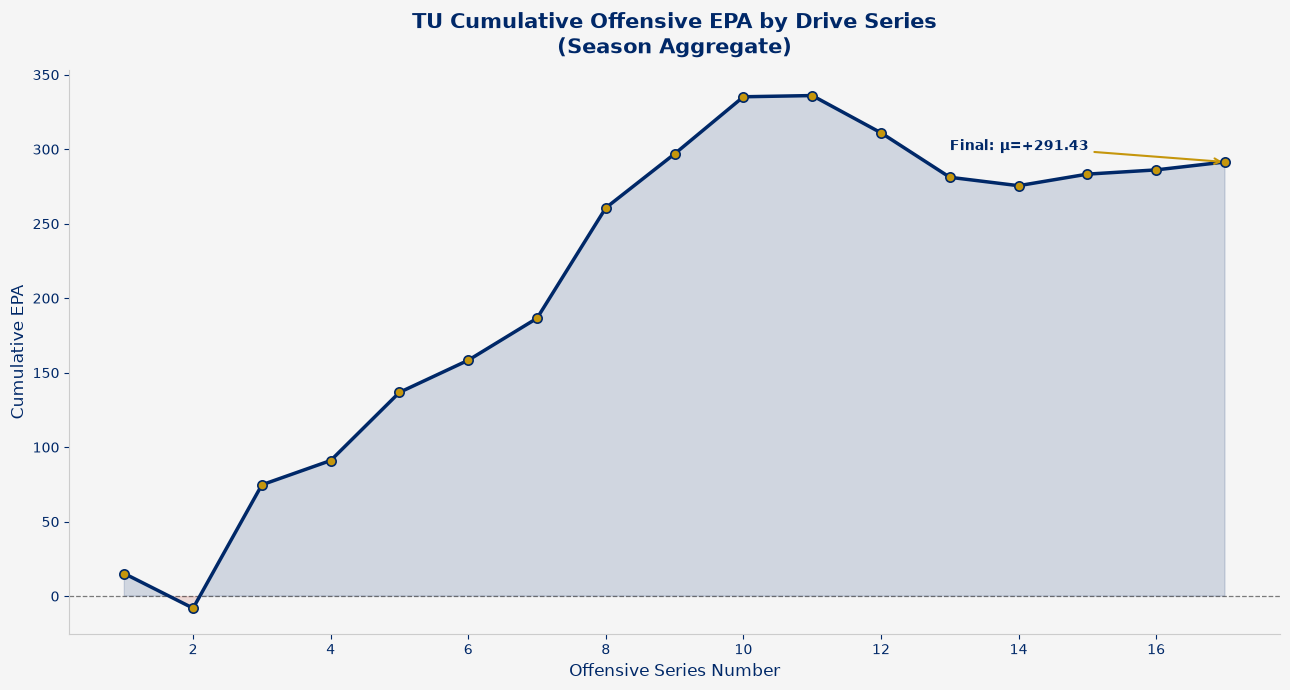

In [25]:
# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Aggregate EPA by series across all games
series_df = (
    off_df.groupby('off_series')['epa']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
    .rename(columns={'sum': 'total_epa', 'mean': 'avg_epa', 'count': 'n_plays'})
)

# Filter to series with enough plays to be meaningful
series_df = series_df[series_df['n_plays'] >= 5]

# Cumulative EPA across series
series_df['cumulative_epa'] = series_df['total_epa'].cumsum()

# Plot
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

# Shaded area under the curve
ax.fill_between(
    series_df['off_series'],
    series_df['cumulative_epa'],
    0,
    where=series_df['cumulative_epa'] >= 0,
    alpha=0.15, color=TU_BLUE, interpolate=True
)
ax.fill_between(
    series_df['off_series'],
    series_df['cumulative_epa'],
    0,
    where=series_df['cumulative_epa'] < 0,
    alpha=0.15, color='#C0392B', interpolate=True
)

# Main cumulative EPA line
ax.plot(
    series_df['off_series'],
    series_df['cumulative_epa'],
    color=TU_BLUE, linewidth=2.5, zorder=3
)

# Dot at each series
ax.scatter(
    series_df['off_series'],
    series_df['cumulative_epa'],
    color=TU_GOLD, edgecolors=TU_BLUE, linewidth=1.2,
    s=45, zorder=4
)

# Zero reference line
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

# Annotate final cumulative EPA
final_val = series_df['cumulative_epa'].iloc[-1]
final_ser = series_df['off_series'].iloc[-1]
ax.annotate(
    f'Final: μ={final_val:+.2f}',
    xy=(final_ser, final_val),
    xytext=(final_ser - 4, final_val + (8 if final_val >= 0 else -8)), # change text location here
    fontsize=10, fontweight='bold',
    color=TU_BLUE if final_val >= 0 else '#C0392B',
    arrowprops=dict(arrowstyle='->', color=TU_GOLD, lw=1.5)
)

ax.set_title('TU Cumulative Offensive EPA by Drive Series\n(Season Aggregate)',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Offensive Series Number', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Cumulative EPA', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tu_cumulative_epa_by_series.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Cumulative EPA Per Game by Drive Visualization

In [26]:
import plotly.graph_objects as go

# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# ── Explosive flags ───────────────────────────────────────────────────────────
off_df['run_explosive']  = (
    (off_df['play_type'] == 'run') &
    (off_df['gn_ls'].notna()) &
    (off_df['gn_ls'] >= 12)
).astype(int)

off_df['pass_explosive'] = (
    (off_df['play_type'] == 'pass') &
    (off_df['gn_ls'].notna()) &
    (off_df['gn_ls'] >= 21)
).astype(int)

# ── Drive outcome classification (same logic as Drive Process viz) ─────────────
all_plays = tu_df.copy()
all_plays['play'] = pd.to_numeric(all_plays['play'], errors='coerce')
all_plays = all_plays.sort_values(['game_id', 'play']).reset_index(drop=True)

def classify_outcome(group):
    last = group.iloc[-1]
    nxt  = last['next_odk'] if pd.notna(last['next_odk']) else ''
    tod  = last['turnover_on_downs'] if 'turnover_on_downs' in last.index else 0

    if last['score_event'] == 7:
        return 'Touchdown'

    last_idx = all_plays[
        (all_plays['game_id'] == last['game_id']) &
        (all_plays['play'] == last['play'])
    ].index
    if len(last_idx) > 0:
        next_idx = last_idx[0] + 1
        if next_idx < len(all_plays):
            next_row = all_plays.iloc[next_idx]
            if next_row['game_id'] == last['game_id'] and next_row['score_event'] == 3:
                return 'Field Goal'

    if   tod == 1:   return 'Turnover on Downs'
    elif nxt == 'd': return 'Turnover'
    elif nxt == 'k': return 'Punt'
    else:            return 'Other'

# Build outcome per series
off_plays_sorted = off_df.sort_values(['game_id', 'play'] if 'play' in off_df.columns else ['game_id']).copy()
off_plays_sorted['play'] = pd.to_numeric(off_plays_sorted['play'], errors='coerce')
off_plays_sorted = off_plays_sorted.sort_values(['game_id', 'play'])

series_outcomes = (
    off_plays_sorted
    .groupby(['game_id', 'off_series'], sort=False)
    .apply(classify_outcome)
    .reset_index()
    .rename(columns={0: 'outcome'})
)

# ── Aggregate EPA + explosives by game and series ─────────────────────────────
game_series_df = (
    off_df.groupby(['game_id', 'opp_name', 'game_date', 'team_pts', 'opp_pts', 'win', 'off_series'])
    .agg(
        total_epa     = ('epa',           'sum'),
        n_plays       = ('epa',           'count'),
        run_explosive = ('run_explosive',  'sum'),
        pass_explosive= ('pass_explosive', 'sum'),
    )
    .reset_index()
)

game_series_df = game_series_df[game_series_df['n_plays'] >= 1]

# Merge in outcomes
game_series_df = game_series_df.merge(series_outcomes, on=['game_id', 'off_series'], how='left')
game_series_df['outcome'] = game_series_df['outcome'].fillna('Other')

# Cumulative EPA per game
game_series_df['cumulative_epa'] = (
    game_series_df.groupby('game_id')['total_epa'].cumsum()
)

# Parse dates and extract year
game_series_df['game_date_parsed'] = pd.to_datetime(
    game_series_df['game_date'], format='%m/%d/%Y'
)
game_series_df['year'] = game_series_df['game_date_parsed'].dt.year

# Build full game label
def build_label(row):
    result = 'W' if row['win'] == 1 else 'L'
    return f"{row['game_date']} vs. {row['opp_name']} ({result} {int(row['team_pts'])}-{int(row['opp_pts'])})"

game_series_df['game_label'] = game_series_df.apply(build_label, axis=1)

# Get one row per game, sorted newest → oldest
game_meta = (
    game_series_df[['game_id', 'game_label', 'game_date_parsed', 'year']]
    .drop_duplicates('game_id')
    .sort_values('game_date_parsed', ascending=False)
)

# Color palette
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# Build Plotly figure
fig = go.Figure()

current_year  = None
game_count    = 0
game_indices  = []
trace_index   = 0

for _, meta in game_meta.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_df[game_series_df['game_id'] == game_id]
    color   = colors[game_count % len(colors)]
    game_count += 1

    # Year header
    if year != current_year:
        current_year = year
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>',
            showlegend=True,
            hoverinfo='skip',
            visible=True,
            legendgroup=f'year_{year}',
        ))
        trace_index += 1

    hover_text = [
        f"<b>{label}</b><br>"
        f"Series: {int(row.off_series)}<br>"
        f"Series EPA: {row.total_epa:+.3f}<br>"
        f"Cumulative EPA: {row.cumulative_epa:+.3f}<br>"
        f"Plays in series: {int(row.n_plays)}<br>"
        f"Run explosives: {int(row.run_explosive)}  |  Pass explosives: {int(row.pass_explosive)}<br>"
        f"Outcome: {row.outcome}"
        for row in group.itertuples()
    ]

    fig.add_trace(go.Scatter(
        x=group['off_series'],
        y=group['cumulative_epa'],
        mode='lines+markers',
        name=label,
        legendgroup=game_id,
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>',
        text=hover_text,
        visible='legendonly'
    ))
    game_indices.append(trace_index)
    trace_index += 1

# Zero reference line
fig.add_hline(
    y=0, line_dash='dash',
    line_color='black', opacity=0.4, line_width=1.5
)

fig.update_layout(
    title=dict(
        text='TU Cumulative Offensive EPA by Drive Series<br>'
             '<sup>Click a game to add it — click again to remove — click a year header to toggle all games in that year</sup>',
        font=dict(size=18, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title='Offensive Series Number',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False
    ),
    yaxis=dict(
        title='Cumulative EPA',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False
    ),
    legend=dict(
        title=dict(text='Game', font=dict(color=TU_BLUE, size=11)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        font=dict(size=10),
        itemclick='toggle',
        itemdoubleclick=False,
        tracegroupgap=2
    ),
    updatemenus=[
        dict(
            type='buttons',
            showactive=False,
            x=1.0, xanchor='right',
            y=1.08, yanchor='top',
            buttons=[
                dict(
                    label='Show All',
                    method='restyle',
                    args=[{'visible': True}, game_indices]
                ),
                dict(
                    label='Hide All',
                    method='restyle',
                    args=[{'visible': 'legendonly'}, game_indices]
                )
            ],
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=10)
        )
    ],
    plot_bgcolor=LIGHT_GRAY,
    paper_bgcolor=LIGHT_GRAY,
    hovermode='closest',
    height=650,
    margin=dict(t=120, b=60, l=70, r=20)
)

fig.show()
fig.write_html(FIG_DIR / 'tu_cumulative_epa_per_game_interactive.html')

/tmp/ipykernel_977/2581817299.py:63: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Cumulative EPA per Drive Visualization (win/loss)

In [27]:
import plotly.graph_objects as go
import pandas as pd

# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'
WIN_COLOR  = '#1D9E75'
LOSS_COLOR = '#D85A30'

# Aggregate EPA by game and series
game_series_df = (
    off_df.groupby(['game_id', 'opp_name', 'game_date', 'team_pts', 'opp_pts', 'win', 'off_series'])['epa']
    .agg(['sum', 'count'])
    .reset_index()
    .rename(columns={'sum': 'total_epa', 'count': 'n_plays'})
)

game_series_df = game_series_df[game_series_df['n_plays'] >= 1]

game_series_df['cumulative_epa'] = (
    game_series_df.groupby('game_id')['total_epa'].cumsum()
)

# Parse dates and extract year
game_series_df['game_date_parsed'] = pd.to_datetime(
    game_series_df['game_date'], format='%m/%d/%Y'
)
game_series_df['year'] = game_series_df['game_date_parsed'].dt.year

# Build full game label
def build_label(row):
    result = 'W' if row['win'] == 1 else 'L'
    return f"{row['game_date']} vs. {row['opp_name']} ({result} {int(row['team_pts'])}-{int(row['opp_pts'])})"

game_series_df['game_label'] = game_series_df.apply(build_label, axis=1)

# Get one row per game, sorted newest -> oldest
game_meta = (
    game_series_df[['game_id', 'game_label', 'game_date_parsed', 'year', 'win']]
    .drop_duplicates('game_id')
    .sort_values('game_date_parsed', ascending=False)
)

all_years = sorted(game_meta['year'].unique())

# Year color palette
YEAR_PALETTE = [
    '#002868', '#C5960C', '#1D9E75', '#D85A30', '#9467bd',
    '#378ADD', '#BA7517', '#e377c2', '#17becf', '#8c564b',
]
year_color_map = {yr: YEAR_PALETTE[i % len(YEAR_PALETTE)]
                  for i, yr in enumerate(all_years)}

# Build Plotly figure
fig = go.Figure()

current_year    = None
game_count      = 0
game_indices    = []   # all game line trace indices (both sets)
year_traces     = []   # indices of year-colored traces
wl_traces       = []   # indices of W/L-colored traces
trace_index     = 0

# ── Set A: colored by year ────────────────────────────────────────────────────
for _, meta in game_meta.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_df[game_series_df['game_id'] == game_id]
    color   = year_color_map[year]
    game_count += 1

    # Year header separator in legend
    if year != current_year:
        current_year = year
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>',
            showlegend=True,
            hoverinfo='skip',
            visible=True,
            legendgroup=f'year_header_{year}',
        ))
        trace_index += 1

    hover_text = [
        f"<b>{label}</b><br>"
        f"Series: {int(row.off_series)}<br>"
        f"Series EPA: {row.total_epa:+.3f}<br>"
        f"Cumulative EPA: {row.cumulative_epa:+.3f}<br>"
        f"Plays in series: {int(row.n_plays)}"
        for row in group.itertuples()
    ]

    fig.add_trace(go.Scatter(
        x=group['off_series'],
        y=group['cumulative_epa'],
        mode='lines+markers',
        name=label,
        legendgroup=game_id,
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>',
        text=hover_text,
        visible='legendonly',
    ))
    year_traces.append(trace_index)
    game_indices.append(trace_index)
    trace_index += 1

# ── Set B: colored by W/L ─────────────────────────────────────────────────────
current_year = None
wl_legend_added = set()

for _, meta in game_meta.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_df[game_series_df['game_id'] == game_id]
    color   = WIN_COLOR if meta['win'] == 1 else LOSS_COLOR
    wl_key  = 'Win' if meta['win'] == 1 else 'Loss'

    # Year header separator in legend
    if year != current_year:
        current_year = year
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>',
            showlegend=True,
            hoverinfo='skip',
            visible=False,
            legendgroup=f'wl_header_{year}',
        ))
        trace_index += 1

    hover_text = [
        f"<b>{label}</b><br>"
        f"Series: {int(row.off_series)}<br>"
        f"Series EPA: {row.total_epa:+.3f}<br>"
        f"Cumulative EPA: {row.cumulative_epa:+.3f}<br>"
        f"Plays in series: {int(row.n_plays)}"
        for row in group.itertuples()
    ]

    fig.add_trace(go.Scatter(
        x=group['off_series'],
        y=group['cumulative_epa'],
        mode='lines+markers',
        name=label,
        legendgroup=f'wl_{game_id}',
        showlegend=True,
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>',
        text=hover_text,
        visible=False,
    ))
    wl_traces.append(trace_index)
    game_indices.append(trace_index)
    trace_index += 1

total_traces = trace_index

# ── Color mode toggle ─────────────────────────────────────────────────────────
def make_visibility(mode):
    vis = []
    for i in range(total_traces):
        if mode == 'year':
            vis.append(False if i in wl_traces else ('legendonly' if i in year_traces else True))
        else:
            vis.append(False if i in year_traces else ('legendonly' if i in wl_traces else True))
    return vis

# Zero reference line
fig.add_hline(
    y=0, line_dash='dash',
    line_color='black', opacity=0.4, line_width=1.5
)

fig.update_layout(
    title=dict(
        text='TU Cumulative Offensive EPA by Drive Series<br>'
             '<sup>Click a game to add it — click again to remove — click a year header to toggle all games in that year</sup>',
        font=dict(size=18, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center',
    ),
    xaxis=dict(
        title='Offensive Series Number',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False,
    ),
    yaxis=dict(
        title='Cumulative EPA',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False,
    ),
    legend=dict(
        title=dict(text='Game', font=dict(color=TU_BLUE, size=11)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        font=dict(size=10),
        itemclick='toggle',
        itemdoubleclick=False,
        tracegroupgap=2,
    ),
    updatemenus=[
        # ── Color mode toggle ──────────────────────────────────────────────
        dict(
            type='buttons',
            direction='right',
            showactive=True,
            x=0.5, xanchor='center',
            y=1.08, yanchor='top',
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=10),
            buttons=[
                dict(
                    label='Color by Year',
                    method='restyle',
                    args=[{'visible': make_visibility('year')}],
                ),
                dict(
                    label='Color by W/L',
                    method='restyle',
                    args=[{'visible': make_visibility('wl')}],
                ),
            ],
        ),
        # ── Show / Hide all ────────────────────────────────────────────────
        dict(
            type='buttons',
            showactive=False,
            x=1.0, xanchor='right',
            y=1.08, yanchor='top',
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=10),
            buttons=[
                dict(
                    label='Show All',
                    method='restyle',
                    args=[{'visible': True}, game_indices],
                ),
                dict(
                    label='Hide All',
                    method='restyle',
                    args=[{'visible': 'legendonly'}, game_indices],
                ),
            ],
        ),
    ],
    plot_bgcolor=LIGHT_GRAY,
    paper_bgcolor=LIGHT_GRAY,
    hovermode='closest',
    height=650,
    margin=dict(t=140, b=60, l=70, r=20),
)

fig.show()

Drive Process Visualization

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. Build drive-level data ─────────────────────────────────────────────────

# Keep all rows for lookup, but only build drives from offensive plays
all_plays = tu_df.copy()
all_plays['play'] = pd.to_numeric(all_plays['play'], errors='coerce')
all_plays = all_plays.sort_values(['game_id', 'play']).reset_index(drop=True)

off_plays = all_plays[
    (all_plays['odk'] == 'o') &
    (all_plays['epa'].notna())
].copy()

off_plays['year'] = pd.to_datetime(
    off_plays['game_date'], format='%m/%d/%Y'
).dt.year

off_plays['drive_key'] = (
    off_plays['game_id'].astype(str) + '_s' +
    off_plays['off_series'].astype(str)
)

def classify_outcome(group):
    last     = group.iloc[-1]
    nxt      = last['next_odk'] if pd.notna(last['next_odk']) else ''
    tod      = last['turnover_on_downs'] if 'turnover_on_downs' in last.index else 0

    # Check last offensive play for TD
    if last['score_event'] == 7:
        return 'Touchdown'

    # Check next row after drive for FG
    last_idx = all_plays[
        (all_plays['game_id'] == last['game_id']) &
        (all_plays['play'] == last['play'])
    ].index
    if len(last_idx) > 0:
        next_idx = last_idx[0] + 1
        if next_idx < len(all_plays):
            next_row = all_plays.iloc[next_idx]
            if next_row['game_id'] == last['game_id'] and next_row['score_event'] == 3:
                return 'Field Goal'

    if   tod == 1:   return 'Turnover on Downs'
    elif nxt == 'd': return 'Turnover'
    elif nxt == 'k': return 'Punt'
    else:            return 'Other'

records = []
for key, grp in off_plays.groupby('drive_key', sort=False):
    grp = grp.sort_values('play')
    outcome = classify_outcome(grp)
    records.append({
        'drive_key'  : key,
        'outcome'    : outcome,
        'net_epa'    : round(grp['epa'].sum(), 3),
        'drive_pts'  : 7 if outcome == 'Touchdown' else 3 if outcome == 'Field Goal' else 0,
        'n_plays'    : len(grp),
        'std_epa'    : round(grp['epa'].std() if len(grp) > 1 else 0.0, 3),
        'epa_series' : grp['epa'].tolist(),
        'game_id'    : grp['game_id'].iloc[0],
        'opp_name'   : grp['opp_name'].iloc[0] if 'opp_name' in grp.columns else '',
        'year'       : int(grp['year'].iloc[0]),
        'win'        : int(grp['win'].iloc[0]),
        'team_pts'   : int(grp['team_pts'].iloc[0]),
        'opp_pts'    : int(grp['opp_pts'].iloc[0]),
    })

drives_df = pd.DataFrame(records)
all_years = sorted(drives_df['year'].unique())

OUTCOME_COLORS = {
    'Touchdown'         : '#1D9E75',
    'Field Goal'        : '#378ADD',
    'Punt'              : '#888780',
    'Turnover'          : '#D85A30',
    'Turnover on Downs' : '#BA7517',
    'Other'             : '#B4B2A9',
}
OUTCOME_SYMBOLS = {
    'Touchdown'         : 'circle',
    'Field Goal'        : 'diamond',
    'Punt'              : 'square',
    'Turnover'          : 'x',
    'Turnover on Downs' : 'triangle-up',
    'Other'             : 'cross',
}
N_NORM = 24

def make_hover(row):
    result = 'W' if row['win'] else 'L'
    return (f"vs {row['opp_name']}  {row['team_pts']}-{row['opp_pts']} ({result})<br>"
            f"Drive {row['drive_key'].split('_s')[-1]}  |  "
            f"Net EPA: {row['net_epa']:+.2f}  |  "
            f"Pts: {row['drive_pts']}  |  "
            f"Plays: {row['n_plays']}  |  "
            f"StdDev: {row['std_epa']:.2f}")

# ── 2. Build filter scopes ────────────────────────────────────────────────────
# A scope is identified by (year_label, game_id_or_None)
# We pre-render one set of traces per scope and toggle visibility.

scopes = []  # list of (year_label, game_label, subset_df)

# All seasons / All games
scopes.append(('All seasons', 'All games', drives_df))

for yr in all_years:
    yr_df = drives_df[drives_df['year'] == yr]
    # Year-level, all games
    scopes.append((str(yr), 'All games', yr_df))
    # Individual games within year
    for _, grow in yr_df.drop_duplicates('game_id').sort_values('game_id').iterrows():
        result = 'W' if grow['win'] else 'L'
        glabel = f"vs {grow['opp_name']}  ({grow['team_pts']}-{grow['opp_pts']} {result})"
        scopes.append((str(yr), glabel, yr_df[yr_df['game_id'] == grow['game_id']]))

# ── 3. Pre-build all traces ───────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(' ', ' '),   # placeholders — overridden by layout title
    vertical_spacing=0.13,
    row_heights=[0.46, 0.54],
)

rng = np.random.default_rng(42)
x_norm = np.linspace(0, 1, N_NORM)

all_traces      = []   # (trace, row, col)
scope_trace_map = []   # list of trace-index lists, one per scope

global_idx = 0

for yr_lbl, gm_lbl, sub in scopes:
    scope_indices = []

    if sub.empty:
        scope_trace_map.append(scope_indices)
        continue

    # Scatter traces
    scatter_added = set()
    for outcome in OUTCOME_COLORS:
        mask = sub['outcome'] == outcome
        if not mask.any():
            continue
        grp    = sub[mask]
        jitter = rng.uniform(-0.18, 0.18, size=len(grp))
        labels = [make_hover(r) for _, r in grp.iterrows()]
        t = go.Scatter(
            x=grp['net_epa'],
            y=grp['drive_pts'] + jitter,
            mode='markers',
            name=outcome,
            marker=dict(
                color=OUTCOME_COLORS[outcome],
                symbol=OUTCOME_SYMBOLS[outcome],
                size=9, opacity=0.82,
                line=dict(width=0.6, color='white'),
            ),
            text=labels,
            hovertemplate='%{text}<extra></extra>',
            legendgroup=outcome,
            showlegend=(outcome not in scatter_added),
            visible=False,
        )
        all_traces.append((t, 1, 1))
        scope_indices.append(global_idx)
        global_idx += 1
        scatter_added.add(outcome)

    # Trajectory traces
    outcome_traj = {o: [] for o in OUTCOME_COLORS}
    for _, row in sub.iterrows():
        epas = row['epa_series']
        if len(epas) < 2:
            continue
        cum   = np.cumsum(epas)
        x_raw = np.linspace(0, 1, len(cum))
        y_i   = np.interp(x_norm, x_raw, cum)
        outcome_traj[row['outcome']].append(y_i)
        t = go.Scatter(
            x=x_norm, y=np.round(y_i, 3),
            mode='lines',
            line=dict(color=OUTCOME_COLORS[row['outcome']], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip',
            legendgroup=row['outcome'],
            visible=False,
        )
        all_traces.append((t, 2, 1))
        scope_indices.append(global_idx)
        global_idx += 1

    # Bold average lines
    avg_added = set()
    for outcome, tlist in outcome_traj.items():
        if not tlist:
            continue
        avg = np.mean(tlist, axis=0)
        t = go.Scatter(
            x=x_norm, y=np.round(avg, 3),
            mode='lines',
            name=outcome,
            line=dict(color=OUTCOME_COLORS[outcome], width=3),
            showlegend=False,
            legendgroup=outcome,
            hovertemplate=f'{outcome} avg: %{{y:.2f}}<extra></extra>',
            visible=False,
        )
        all_traces.append((t, 2, 1))
        scope_indices.append(global_idx)
        global_idx += 1
        avg_added.add(outcome)

    scope_trace_map.append(scope_indices)

for t, row, col in all_traces:
    fig.add_trace(t, row=row, col=col)

total_traces = global_idx

# Make first scope visible by default
for idx in scope_trace_map[0]:
    fig.data[idx].visible = True

# ── 4. Build year and game button sets ────────────────────────────────────────
# Year buttons — each selects all scopes whose year matches (all games view)
# Game buttons — each selects a specific game within the active year

def scope_visibility(scope_i):
    vis = [False] * total_traces
    for idx in scope_trace_map[scope_i]:
        vis[idx] = True
    return vis

def subtitle(sub):
    n       = len(sub)
    avg_epa = sub['net_epa'].mean() if n else 0
    td_rate = (sub['outcome'] == 'Touchdown').mean() * 100 if n else 0
    to_rate = sub['outcome'].isin(['Turnover','Turnover on Downs']).mean() * 100 if n else 0
    return (f"{n} drives  ·  Avg EPA {avg_epa:+.2f}  ·  "
            f"TD rate {td_rate:.0f}%  ·  TO rate {to_rate:.0f}%")

# Year dropdown buttons
year_buttons = []
for yr_val in ['All seasons'] + [str(y) for y in all_years]:
    # find the "all games" scope for this year
    scope_i = next(
        i for i, (yl, gl, _) in enumerate(scopes)
        if yl == yr_val and gl == 'All games'
    )
    sub = scopes[scope_i][2]
    year_buttons.append(dict(
        label  = yr_val,
        method = 'update',
        args   = [
            {'visible': scope_visibility(scope_i)},
            {'title.text': (
                f'<b>TU Offensive Drive EPA</b>   '
                f'{"— " + yr_val if yr_val != "All seasons" else "— All seasons"}<br>'
                f'<sup style="color:#888780">{subtitle(sub)}</sup>'
            )}
        ]
    ))


# ── Single combined dropdown ──────────────────────────────────────────────────
combined_buttons = []

# All seasons entry
combined_buttons.append(dict(
    label  = '— All Seasons —',
    method = 'update',
    args   = [
        {'visible': scope_visibility(0)},
        {'title.text': (
            '<b>TU Offensive Drive EPA</b>   — All seasons<br>'
            f'<sup style="color:#888780">{subtitle(drives_df)}</sup>'
        )}
    ]
))

for yr in all_years:
    # Year header entry
    yr_scope_i = next(
        i for i, (yl, gl, _) in enumerate(scopes)
        if yl == str(yr) and gl == 'All games'
    )
    yr_sub = scopes[yr_scope_i][2]
    combined_buttons.append(dict(
        label  = f'── {yr} ──',
        method = 'update',
        args   = [
            {'visible': scope_visibility(yr_scope_i)},
            {'title.text': (
                f'<b>TU Offensive Drive EPA</b>   — {yr}<br>'
                f'<sup style="color:#888780">{subtitle(yr_sub)}</sup>'
            )}
        ]
    ))

    # Individual games within that year
    for i, (yr_lbl, gm_lbl, sub) in enumerate(scopes):
        if yr_lbl != str(yr) or gm_lbl == 'All games':
            continue
        combined_buttons.append(dict(
            label  = f'  › {gm_lbl}',
            method = 'update',
            args   = [
                {'visible': scope_visibility(i)},
                {'title.text': (
                    f'<b>TU Offensive Drive EPA</b>   — {yr}  ›  {gm_lbl}<br>'
                    f'<sup style="color:#888780">{subtitle(sub)}</sup>'
                )}
            ]
        ))

# ── 5. Assemble layout ────────────────────────────────────────────────────────
init_sub = scopes[0][2]

fig.update_layout(
    title=dict(
        text=(
            '<b>TU Offensive Drive EPA</b>   — All seasons<br>'
            f'<sup style="color:#888780">{subtitle(init_sub)}</sup>'
        ),
        font=dict(size=15, color='#2C2C2A'),
        x=0.0,
        xanchor='left',
        y=0.97,
        yanchor='top',
        pad=dict(l=10),
    ),
    height=900,
    plot_bgcolor='#FAFAF8',
    paper_bgcolor='#FAFAF8',
    font=dict(family='Arial', color='#5F5E5A', size=11),
    legend=dict(
        title=dict(text='Outcome'),
        x=1.02, y=0.98,
        bgcolor='rgba(250,250,248,0.9)',
        bordercolor='#D3D1C7',
        borderwidth=0.5,
    ),
    margin=dict(l=60, r=160, t=160, b=55),
    hovermode='closest',
    updatemenus=[
        dict(
            buttons   = combined_buttons,
            direction = 'down',
            showactive= True,
            x=0.0,
            xanchor='left',
            y=1.09,
            yanchor='top',
            bgcolor='#FFFFFF',
            bordercolor='#D3D1C7',
            borderwidth=0.5,
            font=dict(size=11, color='#2C2C2A'),
            pad=dict(r=10),
        ),
    ],
    annotations=[
        dict(
            text='Season / Game', showarrow=False,
            x=0.0, xanchor='left',
            y=1.135, yanchor='bottom',
            xref='paper', yref='paper',
            font=dict(size=10, color='#888780'),
        ),
        dict(
            text='<b>Drive Outcomes</b> — Net EPA vs Drive Points',
            showarrow=False,
            x=0.0, xanchor='left',
            y=0.97, yanchor='top',
            xref='paper', yref='paper',
            font=dict(size=12, color='#2C2C2A'),
        ),
        dict(
            text='<b>Drive Process</b> — Cumulative EPA trajectories  '
                 '<i>(thin = individual drives · bold = outcome average)</i>',
            showarrow=False,
            x=0.0, xanchor='left',
            y=0.46, yanchor='top',
            xref='paper', yref='paper',
            font=dict(size=12, color='#2C2C2A'),
        ),
    ],
)

# Reference lines
fig.add_vline(x=0, line_width=1, line_dash='dot', line_color='#C4C2BA', row=1, col=1)
fig.add_hline(y=0, line_width=1, line_dash='dot', line_color='#C4C2BA', row=2, col=1)

fig.update_xaxes(
    title_text='Net Drive EPA  (EP_terminal − EP_initial)',
    gridcolor='#EEEDFE', zerolinecolor='#D3D1C7',
    title_font_size=11, row=1, col=1
)
fig.update_yaxes(
    title_text='Drive Points',
    gridcolor='#EEEDFE', zerolinecolor='#D3D1C7',
    title_font_size=11, row=1, col=1
)
fig.update_xaxes(
    title_text='Drive progression  (0 = first play  →  1 = last play, normalized)',
    gridcolor='#EEEDFE', zerolinecolor='#D3D1C7',
    tickvals=[0, 0.25, 0.5, 0.75, 1.0],
    ticktext=['Start', '25%', '50%', '75%', 'End'], title_font_size=11, row=2, col=1
)
fig.update_yaxes(
    title_text='Cumulative EPA',
    gridcolor='#EEEDFE', zerolinecolor='#D3D1C7',
    title_font_size=11, row=2, col=1
)

fig.show()

# The Fingerprint

EPA Win/Loss Fingerprint Visualization

In [29]:
# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
WIN_COLOR  = '#2ca02c'
LOSS_COLOR = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Parse year
off_df['game_date_parsed'] = pd.to_datetime(
    off_df['game_date'], format='%m/%d/%Y'
)
off_df['year'] = off_df['game_date_parsed'].dt.year
years          = sorted(off_df['year'].unique(), reverse=True)

# Helper: safe mean
def safe_mean(series):
    return series.mean() if len(series) > 0 else 0

# Compute metrics split by win/loss for a given dataframe
def build_metrics(df):
    run_df  = df[df['play_type'] == 'run']
    pass_df = df[df['play_type'] == 'pass']
    dn1_df  = df[df['dn'] == 1]
    dn2_df  = df[df['dn'] == 2]
    dn3_df  = df[(df['dn'] == 3) & (df['dist'].notna())].copy()
    rz_df   = df[df['yard_ln'] >= 20]

    if len(dn3_df) > 0:
        convert_results = ['complete', 'rush', 'scramble',
                           'complete, td', 'rush, td']
        dn3_df['converted'] = (
            dn3_df['result'].str.strip().str.lower().isin(convert_results) &
            (dn3_df['gn_ls'] >= dn3_df['dist'])
        )
        conv_rate = dn3_df['converted'].mean()
    else:
        conv_rate = 0

    if df['gn_ls'].notna().any():
        exp_df  = df[
            ((df['play_type'] == 'run')  & (df['gn_ls'] >= 12)) |
            ((df['play_type'] == 'pass') & (df['gn_ls'] >= 21))
        ]
        exp_epa = safe_mean(exp_df['epa'])
    else:
        exp_epa = 0

    return {
        '1st Down EPA'       : safe_mean(dn1_df['epa']),
        '2nd Down EPA'       : safe_mean(dn2_df['epa']),
        '3rd Down EPA'       : safe_mean(dn3_df['epa']),
        'Run EPA'            : safe_mean(run_df['epa']),
        'Pass EPA'           : safe_mean(pass_df['epa']),
        'Red Zone EPA'       : safe_mean(rz_df['epa']),
        'Explosive EPA'      : exp_epa,
        '3rd Down Conv Rate' : conv_rate,
    }

# Normalize metrics to 0-1 across wins + losses
def normalize_metrics(win_metrics, loss_metrics):
    categories = list(win_metrics.keys())
    norm_wins, norm_losses = [], []

    for cat in categories:
        vals = [win_metrics[cat], loss_metrics[cat]]
        vmin = min(vals) - abs(min(vals)) * 0.2
        vmax = max(vals) + abs(max(vals)) * 0.2
        rng  = vmax - vmin if vmax != vmin else 1
        norm_wins.append((win_metrics[cat] - vmin) / rng)
        norm_losses.append((loss_metrics[cat] - vmin) / rng)

    return norm_wins, norm_losses

# Build traces for a given year filter
def build_traces(df):
    categories = ['1st Down EPA', '2nd Down EPA', '3rd Down EPA',
                  'Run EPA', 'Pass EPA', 'Red Zone EPA',
                  'Explosive EPA', '3rd Down Conv Rate']

    wins_df   = df[df['win'] == 1]
    losses_df = df[df['win'] == 0]

    win_metrics  = build_metrics(wins_df)
    loss_metrics = build_metrics(losses_df)

    norm_wins, norm_losses = normalize_metrics(win_metrics, loss_metrics)

    raw_wins   = [win_metrics[c]  for c in categories]
    raw_losses = [loss_metrics[c] for c in categories]

    # Close polygons
    cats_closed   = categories + [categories[0]]
    nw_closed     = norm_wins   + [norm_wins[0]]
    nl_closed     = norm_losses + [norm_losses[0]]
    rw_closed     = raw_wins    + [raw_wins[0]]
    rl_closed     = raw_losses  + [raw_losses[0]]

    # Win/loss record
    game_records = (
        df.groupby(['game_id', 'win'])
        .size().reset_index()[['game_id', 'win']]
        .drop_duplicates('game_id')
    )
    n_wins   = (game_records['win'] == 1).sum()
    n_losses = (game_records['win'] == 0).sum()

    # Biggest divergence
    divergence   = [abs(w - l) for w, l in zip(raw_wins, raw_losses)]
    max_div_cat  = categories[divergence.index(max(divergence))]

    return nw_closed, nl_closed, rw_closed, rl_closed, cats_closed, \
           n_wins, n_losses, max_div_cat

# Build figure with all years as frame sets
fig = go.Figure()

# We build one set of traces per year option + one for all years
year_options = ['All Years'] + [str(y) for y in years]

all_traces      = []   # list of (win_trace, loss_trace) per year option
all_titles      = []

for option in year_options:
    if option == 'All Years':
        subset = off_df.copy()
    else:
        subset = off_df[off_df['year'] == int(option)].copy()

    nw, nl, rw, rl, cats, n_wins, n_losses, max_div = build_traces(subset)

    all_traces.append((nw, nl, rw, rl, cats))
    all_titles.append(
        f'TU Offensive EPA Win/Loss Fingerprint — {option}<br>'
        f'<sup>Record: {n_wins}W – {n_losses}L  |  '
        f'Biggest divergence: <b>{max_div}</b>  |  '
        f'Hover for raw values</sup>'
    )

# Add initial traces (All Years)
nw, nl, rw, rl, cats = all_traces[0]
n_wins_all   = sum(1 for _ in off_df.groupby('game_id') if _[1]['win'].iloc[0] == 1)

fig.add_trace(go.Scatterpolar(
    r=nw, theta=cats, fill='toself',
    fillcolor='rgba(44, 160, 44, 0.15)',
    line=dict(color=WIN_COLOR, width=2.5),
    name='Wins',
    customdata=list(zip(rw, cats)),
    hovertemplate='<b>%{customdata[1]}</b><br>Value: %{customdata[0]:.3f}<extra></extra>'
))

fig.add_trace(go.Scatterpolar(
    r=nl, theta=cats, fill='toself',
    fillcolor='rgba(192, 57, 43, 0.15)',
    line=dict(color=LOSS_COLOR, width=2.5),
    name='Losses',
    customdata=list(zip(rl, cats)),
    hovertemplate='<b>%{customdata[1]}</b><br>Value: %{customdata[0]:.3f}<extra></extra>'
))

# Build dropdown buttons
buttons = []
for i, option in enumerate(year_options):
    nw, nl, rw, rl, cats = all_traces[i]
    buttons.append(dict(
        label=option,
        method='update',
        args=[
            {   # update trace data
                'r'          : [nw, nl],
                'theta'      : [cats, cats],
                'customdata' : [
                    list(zip(rw, cats)),
                    list(zip(rl, cats))
                ]
            },
            {   # update title
                'title.text' : all_titles[i]
            }
        ]
    ))

# Layout
fig.update_layout(
    polar=dict(
        bgcolor=LIGHT_GRAY,
        radialaxis=dict(
            visible=True,
            showticklabels=False,
            showline=False,
            gridcolor='#CCCCCC',
            gridwidth=1,
            range=[0, 1]
        ),
        angularaxis=dict(
            tickfont=dict(size=12, color=TU_BLUE, family='Arial'),
            linecolor='#CCCCCC',
            gridcolor='#CCCCCC'
        )
    ),
    updatemenus=[
        dict(
            type='dropdown',
            direction='down',
            x=0.0, xanchor='left',
            y=1.12, yanchor='top',
            buttons=buttons,
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=11),
            showactive=True,
            active=0
        )
    ],
    title=dict(
        text=all_titles[0],
        font=dict(size=18, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    legend=dict(
        font=dict(size=12, color=TU_BLUE),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        x=1.1, y=1.0
    ),
    paper_bgcolor=LIGHT_GRAY,
    height=680,
    margin=dict(t=140, b=60, l=80, r=150)
)

fig.show()
fig.write_html(FIG_DIR / 'tu_epa_win_loss_fingerprint_interactive.html')